# Titanic生存予測：リークのないOOF評価，AD分析，3種類の提出

## 目的

配布された `train_titanic.csv` だけで `Survived` を学習し，未知の `test_titanic.csv` に対するF1スコアの向上を目指す．本ノートブックは次を満たす実験パイプラインである．

- Titanic向け特徴量エンジニアリングと，fold内で完結する欠損補完・頻度集計
- 5-fold Stratified CV，複数seedのOOF確率，F1用閾値最適化
- 3特徴量セット，8モデル，クラス重み，Optuna探索の比較
- OOF多様性に基づく異種モデルsoft voting
- 6個の数値特徴量とk近傍平均距離によるApplicability Domain（AD）分析
- OOFのAD内外性能とtestのAD構成を用いたモデル選択
- 全体最良，AD選択，閾値variantの3提出

## 競技上の制約

使用するデータはこのディレクトリの `train_titanic.csv` と `test_titanic.csv` のみとする．外部Titanicデータ，既知の正解，兄弟ディレクトリの予測結果は参照しない．LLMは分類・特徴量生成・推論パイプラインへ組み込まない．`PassengerId` は提出時の対応付けだけに使い，モデル入力から除外する．testの説明変数はAD内外比率の確認とモデル選択にだけ使用し，testの正解ラベルは使用しない．

> OOFを使っても，同じCVに対する大量探索には過適合し得る．そこで探索はseed 42に固定し，採用候補をseed 123，2026を含む再評価へ進める．AD加重スコアは未知testのF1予測値ではなく，testのAD構成を考慮するための簡易な選択指標として扱う．


## 0．必要ライブラリの準備

このlessonは `uv` 管理である．ノートブックと同じディレクトリで，初回だけ次を実行する．

```bash
uv add "numpy>=2,<3" "pandas>=2.2,<4" "scikit-learn>=1.4,<2" \
  matplotlib optuna catboost lightgbm xgboost jupyter ipykernel
uv run python -m ipykernel install --user --name lesson8-self-code \
  --display-name "Python (lesson8-self-code)"
uv run jupyter lab
```

通常は性能重視の完全モードで動く．構文・一連の処理だけを短時間で確認するときは，起動前に `TITANIC_FAST_MODE=1` を設定する．完全モードのOptuna trial数は環境変数 `TITANIC_OPTUNA_TRIALS` で変更でき，既定は30 trial／モデルである．最終的な提出CSV 3本とAD評価CSVはNotebookと同じディレクトリへ保存する．同名ファイルがあり内容が異なる場合は，上書きせず停止する．


In [1]:
# 1．セットアップと再現性
from __future__ import annotations

import gc
import itertools
import json
import math
import os
import platform
import random
import re
import warnings
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import Markdown, display
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message=r"X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)
warnings.filterwarnings(
    "ignore",
    message=r"Inconsistent values: penalty=.*",
    category=UserWarning,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE_SEED = 42
SEARCH_SEED = 42
FULL_CV_SEEDS = (42, 123, 2026)
FAST_MODE = os.getenv("TITANIC_FAST_MODE", "0") == "1"
CV_SEEDS = (42,) if FAST_MODE else FULL_CV_SEEDS
N_SPLITS = 5
N_OPTUNA_TRIALS = int(
    os.getenv("TITANIC_OPTUNA_TRIALS", "2" if FAST_MODE else "30")
)
ENSEMBLE_WEIGHT_STEP = 0.25 if FAST_MODE else 0.05

os.environ["PYTHONHASHSEED"] = str(BASE_SEED)
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)

DATA_DIR = Path.cwd()
SUBMISSION_DIR = DATA_DIR


def package_version(package_name: str) -> str:
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"


versions = pd.Series(
    {
        "Python": platform.python_version(),
        "NumPy": package_version("numpy"),
        "pandas": package_version("pandas"),
        "scikit-learn": package_version("scikit-learn"),
        "Optuna": package_version("optuna"),
        "CatBoost": package_version("catboost"),
        "LightGBM": package_version("lightgbm"),
        "XGBoost": package_version("xgboost"),
    },
    name="version",
)

print(f"FAST_MODE={FAST_MODE}, CV_SEEDS={CV_SEEDS}, n_splits={N_SPLITS}")
print(f"Optuna trials/model={N_OPTUNA_TRIALS}, ensemble weight step={ENSEMBLE_WEIGHT_STEP}")
print(f"提出CSVの保存先={SUBMISSION_DIR.resolve()}")
display(versions.to_frame())


FAST_MODE=False, CV_SEEDS=(42, 123, 2026), n_splits=5
Optuna trials/model=30, ensemble weight step=0.05
提出CSVの保存先=/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code


,version
Python,3.11.15
NumPy,2.4.6
pandas,3.0.3
scikit-learn,1.9.0
Optuna,4.9.0
CatBoost,1.2.10
LightGBM,4.6.0
XGBoost,3.2.0


## 2．データ読み込みと受入確認

ファイル名を固定し，別ディレクトリのデータを探索しない．`PassengerId` と目的変数は説明変数から分離して保持する．


In [2]:
TRAIN_PATH = DATA_DIR / "train_titanic.csv"
TEST_PATH = DATA_DIR / "test_titanic.csv"

if not TRAIN_PATH.is_file() or not TEST_PATH.is_file():
    raise FileNotFoundError(
        "ノートブックを self_code ディレクトリから実行し，"
        "train_titanic.csv と test_titanic.csv を同じ場所に置いてください．"
    )

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

assert "Survived" in train.columns
assert "Survived" not in test.columns
assert set(train.columns) - {"Survived"} == set(test.columns)
assert set(train["Survived"].unique()) <= {0, 1}

passenger_ids = train["PassengerId"].copy()
test_passenger_ids = test["PassengerId"].copy()
y = train["Survived"].astype(int).copy()
X = train.drop(columns=["Survived", "PassengerId"]).copy()
X_test = test.drop(columns=["PassengerId"]).copy()

print(f"train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"test : {test.shape[0]} rows × {test.shape[1]} columns")
print("モデル入力から除外:", ["PassengerId", "Survived"])


train: 712 rows × 12 columns
test : 179 rows × 11 columns
モデル入力から除外: ['PassengerId', 'Survived']


## 3．EDA

型，欠損，クラス比，カテゴリ数，列構成，重複を先に確認する．表示だけに使う集計であり，この結果をCV前処理へ流用しない．


In [3]:
def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing_count": df.isna().sum(),
            "missing_rate": df.isna().mean(),
        }
    )


print("データ型・欠損（train）")
display(missing_summary(train))
print("データ型・欠損（test）")
display(missing_summary(test))

class_distribution = (
    train["Survived"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)
class_distribution["rate"] = class_distribution["count"] / len(train)
print("目的変数のクラス数・割合")
display(class_distribution)

categorical_candidates = ["Name", "Sex", "Ticket", "Cabin", "Embarked"]
category_uniques = pd.DataFrame(
    {
        "train_nunique": train[categorical_candidates].nunique(dropna=False),
        "test_nunique": test[categorical_candidates].nunique(dropna=False),
    }
)
print("カテゴリ候補のユニーク数")
display(category_uniques)

column_check = pd.DataFrame(
    {
        "train_columns": pd.Series(train.columns, dtype="object"),
        "test_columns": pd.Series(test.columns, dtype="object"),
    }
)
print("trainとtestの列構成")
display(column_check)

duplicate_check = pd.Series(
    {
        "train_duplicate_rows": int(train.duplicated().sum()),
        "test_duplicate_rows": int(test.duplicated().sum()),
        "train_PassengerId_duplicates": int(train["PassengerId"].duplicated().sum()),
        "test_PassengerId_duplicates": int(test["PassengerId"].duplicated().sum()),
        "train_test_PassengerId_overlap": int(
            len(set(train["PassengerId"]) & set(test["PassengerId"]))
        ),
    },
    name="count",
)
print("重複確認")
display(duplicate_check.to_frame())

assert duplicate_check.eq(0).all()
assert len(test) == 179, "レギュレーション記載のtest件数と一致しません．"


データ型・欠損（train）


,dtype,missing_count,missing_rate
PassengerId,int64,0,0.000000
Survived,int64,0,0.000000
Pclass,int64,0,0.000000
Name,str,0,0.000000
Sex,str,0,0.000000
Age,float64,146,0.205056
SibSp,int64,0,0.000000
Parch,int64,0,0.000000
Ticket,str,0,0.000000
Fare,float64,0,0.000000


データ型・欠損（test）


,dtype,missing_count,missing_rate
PassengerId,int64,0,0.000000
Pclass,int64,0,0.000000
Name,str,0,0.000000
Sex,str,0,0.000000
Age,float64,31,0.173184
SibSp,int64,0,0.000000
Parch,int64,0,0.000000
Ticket,str,0,0.000000
Fare,float64,0,0.000000
Cabin,str,135,0.754190


目的変数のクラス数・割合


...

,train_nunique,test_nunique
Name,712,179
Sex,2,2
Ticket,565,168
Cabin,125,44
Embarked,4,3


trainとtestの列構成


,train_columns,test_columns
0,PassengerId,PassengerId
1,Survived,Pclass
2,Pclass,Name
3,Name,Sex
4,Sex,Age
5,Age,SibSp
6,SibSp,Parch
7,Parch,Ticket
8,Ticket,Fare
9,Fare,Cabin


重複確認


,count
train_duplicate_rows,0
test_duplicate_rows,0
train_PassengerId_duplicates,0
test_PassengerId_duplicates,0
train_test_PassengerId_overlap,0


## 4．特徴量設計

### fold内で学習する統計

`TitanicFeatureEngineer.fit()` は，Age/Fare/Embarkedの補完値，Ticket/Surname頻度，希少Deck・TicketPrefix，FareBand境界を受け取った訓練foldだけから学ぶ．`transform()` は保存済み統計を検証foldまたはtestへ適用し，対象側で再集計しない．

### 比較する構成

- Set A：指定された基本7特徴
- Set B：敬称，家族，子ども，Cabinの主要特徴を追加
- Set C：Ticket/Surname頻度と主要相互作用を追加
- Set C extended：Age/Fare band，Cabin/Ticket補助，役割，残りの相互作用を候補ブロックとして追加

敬称は一律 `Rare` と意味別統合，家族区分は3区分と4区分をOOFで比較する．`ChildFamilySize` は「子ども本人のFamilySize（成人は0）」，`AdultFamilySize` はその逆と定義する．生の `Name`，`Surname`，`Ticket`，`Cabin` はモデルへ渡さない．


In [4]:
CORE_TITLES = {"Mr", "Mrs", "Miss", "Master"}
SEMANTIC_TITLE_MAP = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Lady": "Noble",
    "Countess": "Noble",
    "Sir": "Noble",
    "Jonkheer": "Noble",
    "Don": "Noble",
    "Dona": "Noble",
    "Dr": "Professional",
    "Rev": "Professional",
    "Col": "Professional",
    "Major": "Professional",
    "Capt": "Professional",
}


def extract_raw_title(names: pd.Series) -> pd.Series:
    title = names.fillna("").astype(str).str.extract(r",\s*([^.]*)\.", expand=False)
    title = title.fillna("Unknown").str.strip()
    title = title.str.replace(r"^the\s+", "", regex=True, case=False)
    return title.str.title()


def normalize_title(names: pd.Series, strategy: str) -> pd.Series:
    raw = extract_raw_title(names)
    if strategy == "rare":
        return raw.where(raw.isin(CORE_TITLES), "Rare")
    if strategy == "semantic":
        mapped = raw.replace(SEMANTIC_TITLE_MAP)
        allowed = CORE_TITLES | {"Noble", "Professional"}
        return mapped.where(mapped.isin(allowed), "Rare")
    raise ValueError(f"未知のtitle strategy: {strategy}")


def extract_surname(names: pd.Series) -> pd.Series:
    surname = names.fillna("").astype(str).str.extract(r"^([^,]+),", expand=False)
    surname = surname.fillna("UNKNOWN").str.upper().str.strip()
    return surname.str.replace(r"\s+", " ", regex=True)


def normalize_ticket(ticket: pd.Series) -> pd.Series:
    return ticket.fillna("UNKNOWN").astype(str).str.upper().str.strip()


def extract_ticket_prefix(ticket: pd.Series) -> pd.Series:
    normalized = normalize_ticket(ticket)
    prefix = normalized.str.replace(r"\d+\s*$", "", regex=True)
    prefix = prefix.str.replace(r"[^A-Z]+", "", regex=True)
    return prefix.mask(prefix.eq(""), "NONE")


def extract_ticket_number_length(ticket: pd.Series) -> pd.Series:
    normalized = normalize_ticket(ticket)
    suffix = normalized.str.extract(r"(\d+)\s*$", expand=False).fillna("")
    return suffix.str.len().astype(int)


def raw_deck(cabin: pd.Series) -> pd.Series:
    cabin_text = cabin.fillna("").astype(str).str.strip().str.upper()
    deck = cabin_text.str.extract(r"^([A-Z])", expand=False)
    return deck.fillna("Unknown")


FEATURE_PROFILES: dict[str, dict[str, Any]] = {
    "A": {
        "set_name": "A",
        "title_strategy": "rare",
        "family_scheme": "simple3",
        "extended_groups": (),
    },
    "B_rare_simple3": {
        "set_name": "B",
        "title_strategy": "rare",
        "family_scheme": "simple3",
        "extended_groups": (),
    },
    "B_semantic_simple3": {
        "set_name": "B",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": (),
    },
    "B_rare_four": {
        "set_name": "B",
        "title_strategy": "rare",
        "family_scheme": "four",
        "extended_groups": (),
    },
    "B_semantic_four": {
        "set_name": "B",
        "title_strategy": "semantic",
        "family_scheme": "four",
        "extended_groups": (),
    },
    "C_rare_simple3": {
        "set_name": "C",
        "title_strategy": "rare",
        "family_scheme": "simple3",
        "extended_groups": (),
    },
    "C_semantic_simple3": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": (),
    },
    "C_rare_four": {
        "set_name": "C",
        "title_strategy": "rare",
        "family_scheme": "four",
        "extended_groups": (),
    },
    "C_semantic_four": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "four",
        "extended_groups": (),
    },
    "C_plus_bands": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": ("bands",),
    },
    "C_plus_ticket_cabin": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": ("ticket_cabin",),
    },
    "C_plus_roles": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": ("roles",),
    },
    "C_plus_interactions": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": ("interactions",),
    },
    "C_extended": {
        "set_name": "C",
        "title_strategy": "semantic",
        "family_scheme": "simple3",
        "extended_groups": ("bands", "ticket_cabin", "roles", "interactions"),
    },
}

SET_A_NUMERIC = ["Pclass", "Age", "SibSp", "Parch", "FareLog"]
SET_A_CATEGORICAL = ["Sex", "Embarked"]
SET_B_NUMERIC = SET_A_NUMERIC + [
    "AgeMissing", "FamilySize", "IsAlone", "IsChild", "HasCabin"
]
SET_B_CATEGORICAL = SET_A_CATEGORICAL + ["Title", "FamilyGroup", "Deck"]
SET_C_NUMERIC = SET_B_NUMERIC + [
    "TicketGroupSize",
    "SharedTicket",
    "FarePerPerson",
    "SurnameGroupSize",
    "HasFamilySurname",
]
SET_C_CATEGORICAL = SET_B_CATEGORICAL + [
    "TicketPrefix", "Sex_Pclass", "Title_Pclass"
]
EXTENDED_GROUP_COLUMNS: dict[str, tuple[list[str], list[str]]] = {
    "bands": (
        ["FareMissing"],
        ["AgeBand", "FareBand"],
    ),
    "ticket_cabin": (
        ["CabinCount", "TicketNumberLength"],
        [],
    ),
    "roles": (
        ["IsMother", "IsFather", "ChildFamilySize", "AdultFamilySize"],
        [],
    ),
    "interactions": (
        [],
        ["Sex_AgeBand", "Sex_IsChild", "Pclass_Deck", "FamilyGroup_Pclass"],
    ),
}


def feature_columns(profile_key: str) -> tuple[list[str], list[str]]:
    profile = FEATURE_PROFILES[profile_key]
    if profile["set_name"] == "A":
        numeric, categorical = SET_A_NUMERIC, SET_A_CATEGORICAL
    elif profile["set_name"] == "B":
        numeric, categorical = SET_B_NUMERIC, SET_B_CATEGORICAL
    else:
        numeric, categorical = SET_C_NUMERIC, SET_C_CATEGORICAL
    numeric = list(numeric)
    categorical = list(categorical)
    for group_name in profile["extended_groups"]:
        group_numeric, group_categorical = EXTENDED_GROUP_COLUMNS[group_name]
        numeric.extend(group_numeric)
        categorical.extend(group_categorical)
    return numeric, categorical


In [5]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    """fold依存統計をfit時の入力だけから学ぶTitanic用変換器．"""

    def __init__(
        self,
        profile_key: str,
        rare_prefix_min_count: int = 5,
        rare_deck_min_count: int = 5,
    ):
        self.profile_key = profile_key
        self.rare_prefix_min_count = rare_prefix_min_count
        self.rare_deck_min_count = rare_deck_min_count

    def _validate(self, X: pd.DataFrame) -> None:
        required = {
            "Pclass", "Name", "Sex", "Age", "SibSp", "Parch",
            "Ticket", "Fare", "Cabin", "Embarked",
        }
        missing = required - set(X.columns)
        if missing:
            raise ValueError(f"入力に必要な列がありません: {sorted(missing)}")

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None):
        self._validate(X)
        profile = FEATURE_PROFILES[self.profile_key]
        title = normalize_title(X["Name"], profile["title_strategy"])
        surname = extract_surname(X["Name"])
        ticket = normalize_ticket(X["Ticket"])
        prefix = extract_ticket_prefix(X["Ticket"])
        deck = raw_deck(X["Cabin"])

        age_frame = pd.DataFrame(
            {
                "Title": title,
                "Pclass": X["Pclass"].astype(int),
                "Sex": X["Sex"].fillna("Unknown").astype(str),
                "Age": pd.to_numeric(X["Age"], errors="coerce"),
            },
            index=X.index,
        )
        self.age_title_pclass_ = (
            age_frame.groupby(["Title", "Pclass"], observed=True)["Age"].median().to_dict()
        )
        self.age_title_ = age_frame.groupby("Title", observed=True)["Age"].median().to_dict()
        self.age_pclass_sex_ = (
            age_frame.groupby(["Pclass", "Sex"], observed=True)["Age"].median().to_dict()
        )
        self.age_global_ = float(age_frame["Age"].median())

        fare = pd.to_numeric(X["Fare"], errors="coerce")
        fare_frame = pd.DataFrame({"Pclass": X["Pclass"].astype(int), "Fare": fare})
        self.fare_pclass_ = fare_frame.groupby("Pclass", observed=True)["Fare"].median().to_dict()
        self.fare_global_ = float(fare.median())

        embarked = X["Embarked"].dropna().astype(str)
        self.embarked_mode_ = str(embarked.mode().iloc[0]) if not embarked.empty else "Unknown"

        self.ticket_counts_ = ticket.value_counts(dropna=False).to_dict()
        self.surname_counts_ = surname.value_counts(dropna=False).to_dict()

        prefix_counts = prefix.value_counts(dropna=False)
        self.frequent_prefixes_ = set(
            prefix_counts[prefix_counts >= self.rare_prefix_min_count].index
        ) | {"NONE"}
        deck_counts = deck.value_counts(dropna=False)
        self.frequent_decks_ = set(
            deck_counts[deck_counts >= self.rare_deck_min_count].index
        ) | {"Unknown"}

        fare_filled = fare.fillna(X["Pclass"].map(self.fare_pclass_)).fillna(self.fare_global_)
        _, edges = pd.qcut(fare_filled, q=4, retbins=True, duplicates="drop")
        edges = np.unique(np.asarray(edges, dtype=float))
        if len(edges) < 2:
            edges = np.array([-np.inf, np.inf], dtype=float)
        else:
            edges[0], edges[-1] = -np.inf, np.inf
        self.fare_edges_ = edges
        return self

    @staticmethod
    def _map_pair(
        first: pd.Series,
        second: pd.Series,
        mapping: dict[tuple[Any, Any], float],
    ) -> pd.Series:
        keys = pd.Series(list(zip(first, second)), index=first.index)
        return keys.map(mapping)

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        self._validate(X)
        profile = FEATURE_PROFILES[self.profile_key]
        out = pd.DataFrame(index=X.index)

        title = normalize_title(X["Name"], profile["title_strategy"])
        surname = extract_surname(X["Name"])
        ticket = normalize_ticket(X["Ticket"])
        prefix_raw = extract_ticket_prefix(X["Ticket"])
        deck_raw = raw_deck(X["Cabin"])

        age_original = pd.to_numeric(X["Age"], errors="coerce")
        age = age_original.copy()
        age = age.fillna(
            self._map_pair(title, X["Pclass"].astype(int), self.age_title_pclass_)
        )
        age = age.fillna(title.map(self.age_title_))
        age = age.fillna(
            self._map_pair(
                X["Pclass"].astype(int),
                X["Sex"].fillna("Unknown").astype(str),
                self.age_pclass_sex_,
            )
        )
        age = age.fillna(self.age_global_).astype(float)

        fare_original = pd.to_numeric(X["Fare"], errors="coerce")
        fare = (
            fare_original
            .fillna(X["Pclass"].astype(int).map(self.fare_pclass_))
            .fillna(self.fare_global_)
            .clip(lower=0)
            .astype(float)
        )

        ticket_group_size = ticket.map(self.ticket_counts_).fillna(1).astype(int).clip(lower=1)
        surname_group_size = surname.map(self.surname_counts_).fillna(1).astype(int).clip(lower=1)
        family_size = (
            pd.to_numeric(X["SibSp"], errors="coerce").fillna(0)
            + pd.to_numeric(X["Parch"], errors="coerce").fillna(0)
            + 1
        ).astype(int)
        is_child = age.lt(16).astype(int)

        if profile["family_scheme"] == "simple3":
            family_group = pd.cut(
                family_size,
                bins=[0, 1, 4, np.inf],
                labels=["Alone", "Small", "Large"],
            ).astype(str)
        else:
            family_group = pd.cut(
                family_size,
                bins=[0, 1, 3, 5, np.inf],
                labels=["Alone", "Small", "Medium", "Large"],
            ).astype(str)

        deck = deck_raw.where(deck_raw.isin(self.frequent_decks_), "Other")
        prefix = prefix_raw.where(prefix_raw.isin(self.frequent_prefixes_), "RARE")
        cabin_text = X["Cabin"].fillna("").astype(str).str.strip()
        cabin_count = cabin_text.str.split().str.len().where(cabin_text.ne(""), 0).astype(int)
        embarked = X["Embarked"].fillna(self.embarked_mode_).astype(str)
        sex = X["Sex"].fillna("Unknown").astype(str)

        age_band = pd.cut(
            age,
            bins=[-np.inf, 12, 18, 30, 45, 60, np.inf],
            labels=["Child", "Teen", "YoungAdult", "Adult", "MiddleAge", "Senior"],
        ).astype(str)
        fare_band = pd.cut(
            fare,
            bins=self.fare_edges_,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        ).fillna(-1).astype(int).astype(str)

        out["Pclass"] = X["Pclass"].astype(int)
        out["Sex"] = sex
        out["Age"] = age
        out["SibSp"] = pd.to_numeric(X["SibSp"], errors="coerce").fillna(0).astype(int)
        out["Parch"] = pd.to_numeric(X["Parch"], errors="coerce").fillna(0).astype(int)
        out["FareLog"] = np.log1p(fare)
        out["Embarked"] = embarked

        out["Title"] = title.astype(str)
        out["AgeMissing"] = age_original.isna().astype(int)
        out["FamilySize"] = family_size
        out["FamilyGroup"] = family_group
        out["IsAlone"] = family_size.eq(1).astype(int)
        out["IsChild"] = is_child
        out["HasCabin"] = cabin_text.ne("").astype(int)
        out["Deck"] = deck.astype(str)

        out["TicketPrefix"] = prefix.astype(str)
        out["TicketGroupSize"] = ticket_group_size
        out["SharedTicket"] = ticket_group_size.ge(2).astype(int)
        out["FarePerPerson"] = fare / ticket_group_size
        out["SurnameGroupSize"] = surname_group_size
        out["HasFamilySurname"] = surname_group_size.ge(2).astype(int)
        out["Sex_Pclass"] = sex + "_" + X["Pclass"].astype(str)
        out["Title_Pclass"] = title.astype(str) + "_" + X["Pclass"].astype(str)

        out["FareMissing"] = fare_original.isna().astype(int)
        out["CabinCount"] = cabin_count
        out["TicketNumberLength"] = extract_ticket_number_length(X["Ticket"])
        out["IsMother"] = (
            sex.eq("female") & age.ge(18) & X["Parch"].fillna(0).gt(0) & ~title.eq("Miss")
        ).astype(int)
        out["IsFather"] = (
            sex.eq("male") & age.ge(18) & X["Parch"].fillna(0).gt(0) & title.eq("Mr")
        ).astype(int)
        out["ChildFamilySize"] = family_size * is_child
        out["AdultFamilySize"] = family_size * (1 - is_child)
        out["AgeBand"] = age_band
        out["FareBand"] = fare_band
        out["Sex_AgeBand"] = sex + "_" + age_band
        out["Sex_IsChild"] = sex + "_" + is_child.astype(str)
        out["Pclass_Deck"] = X["Pclass"].astype(str) + "_" + deck.astype(str)
        out["FamilyGroup_Pclass"] = family_group + "_" + X["Pclass"].astype(str)

        numeric, categorical = feature_columns(self.profile_key)
        result = out[numeric + categorical].copy()
        for column in categorical:
            result[column] = result[column].fillna("Unknown").astype(str)
        return result


# 変換器の出力仕様だけを確認する．このfit結果は後段のCVや学習には再利用しない．
for profile_key in FEATURE_PROFILES:
    numeric_columns, categorical_columns = feature_columns(profile_key)
    print(
        f"{profile_key:20s}: total={len(numeric_columns) + len(categorical_columns):2d} "
        f"(numeric={len(numeric_columns):2d}, categorical={len(categorical_columns):2d})"
    )


A                   : total= 7 (numeric= 5, categorical= 2)
B_rare_simple3      : total=15 (numeric=10, categorical= 5)
B_semantic_simple3  : total=15 (numeric=10, categorical= 5)
B_rare_four         : total=15 (numeric=10, categorical= 5)
B_semantic_four     : total=15 (numeric=10, categorical= 5)
C_rare_simple3      : total=23 (numeric=15, categorical= 8)
C_semantic_simple3  : total=23 (numeric=15, categorical= 8)
C_rare_four         : total=23 (numeric=15, categorical= 8)
C_semantic_four     : total=23 (numeric=15, categorical= 8)
C_plus_bands        : total=26 (numeric=16, categorical=10)
C_plus_ticket_cabin : total=25 (numeric=17, categorical= 8)
C_plus_roles        : total=27 (numeric=19, categorical= 8)
C_plus_interactions : total=27 (numeric=15, categorical=12)
C_extended          : total=36 (numeric=22, categorical=14)


## 5．モデル別前処理

CatBoostは変換後のカテゴリ列を文字列のまま渡す．残り7モデルは `Pipeline` 内で数値補完，必要に応じた標準化，One-hot encodingを行う．すべてのfitはfold内で実行される．`Fare` と `FareLog` は同時投入せず，線形モデルの不要な多重共線性を避ける．


In [6]:
MODEL_NAMES = [
    "catboost",
    "lightgbm",
    "xgboost",
    "hist_gradient_boosting",
    "extra_trees",
    "random_forest",
    "logistic",
    "svm_rbf",
]

MODEL_FAMILY = {
    "catboost": "boosting",
    "lightgbm": "boosting",
    "xgboost": "boosting",
    "hist_gradient_boosting": "boosting",
    "extra_trees": "bagging",
    "random_forest": "bagging",
    "logistic": "linear_kernel",
    "svm_rbf": "linear_kernel",
}


def default_model_params(model_name: str) -> dict[str, Any]:
    tree_count = 120 if FAST_MODE else 600
    boosting_count = 120 if FAST_MODE else 500
    defaults: dict[str, dict[str, Any]] = {
        "catboost": {
            "iterations": boosting_count,
            "depth": 6,
            "learning_rate": 0.04,
            "l2_leaf_reg": 5.0,
            "random_strength": 1.0,
            "bagging_temperature": 0.5,
            "border_count": 128,
            "class_weight_mode": "none",
        },
        "lightgbm": {
            "n_estimators": boosting_count,
            "learning_rate": 0.03,
            "num_leaves": 20,
            "max_depth": 6,
            "min_child_samples": 20,
            "subsample": 0.85,
            "subsample_freq": 1,
            "colsample_bytree": 0.85,
            "reg_alpha": 0.1,
            "reg_lambda": 1.0,
            "class_weight_mode": "none",
        },
        "xgboost": {
            "n_estimators": boosting_count,
            "learning_rate": 0.03,
            "max_depth": 4,
            "min_child_weight": 2.0,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "gamma": 0.0,
            "reg_alpha": 0.1,
            "reg_lambda": 2.0,
            "class_weight_mode": "none",
        },
        "hist_gradient_boosting": {
            "max_iter": boosting_count,
            "learning_rate": 0.05,
            "max_leaf_nodes": 20,
            "max_depth": 6,
            "min_samples_leaf": 20,
            "l2_regularization": 1.0,
            "class_weight_mode": "none",
        },
        "extra_trees": {
            "n_estimators": tree_count,
            "max_depth": None,
            "min_samples_split": 4,
            "min_samples_leaf": 2,
            "max_features": "sqrt",
            "class_weight_mode": "none",
        },
        "random_forest": {
            "n_estimators": tree_count,
            "max_depth": 8,
            "min_samples_split": 4,
            "min_samples_leaf": 2,
            "max_features": "sqrt",
            "class_weight_mode": "none",
        },
        "logistic": {
            "C": 1.0,
            "penalty": "l2",
            "solver": "liblinear",
            "class_weight_mode": "none",
        },
        "svm_rbf": {
            "C": 2.0,
            "gamma": "scale",
            "class_weight_mode": "none",
        },
    }
    return defaults[model_name].copy()


def class_weight_for_sklearn(mode: str) -> None | str | dict[int, float]:
    if mode == "balanced":
        return "balanced"
    if mode == "positive_1_2":
        return {0: 1.0, 1: 1.2}
    return None


def make_estimator(
    model_name: str,
    params: dict[str, Any] | None,
    seed: int,
) -> BaseEstimator:
    model_params = default_model_params(model_name)
    if params:
        model_params.update(params)
    positive_weight = float(model_params.pop("_positive_weight", 1.0))
    weight_mode = str(model_params.pop("class_weight_mode", "none"))
    class_weight = class_weight_for_sklearn(weight_mode)

    if model_name == "catboost":
        base = {
            "loss_function": "Logloss",
            "verbose": False,
            "allow_writing_files": False,
            "random_seed": seed,
            "thread_count": -1,
        }
        base.update(model_params)
        if weight_mode == "balanced":
            base["auto_class_weights"] = "Balanced"
        elif weight_mode == "positive_1_2":
            base["class_weights"] = [1.0, 1.2]
        return CatBoostClassifier(**base)

    if model_name == "lightgbm":
        return LGBMClassifier(
            objective="binary",
            random_state=seed,
            n_jobs=-1,
            verbosity=-1,
            class_weight=class_weight,
            **model_params,
        )
    if model_name == "xgboost":
        scale_pos_weight = 1.0
        if weight_mode == "balanced":
            scale_pos_weight = positive_weight
        elif weight_mode == "positive_1_2":
            scale_pos_weight = 1.2
        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=seed,
            n_jobs=-1,
            scale_pos_weight=scale_pos_weight,
            **model_params,
        )
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(
            random_state=seed,
            class_weight=class_weight,
            **model_params,
        )
    if model_name == "extra_trees":
        return ExtraTreesClassifier(
            random_state=seed,
            n_jobs=-1,
            class_weight=class_weight,
            **model_params,
        )
    if model_name == "random_forest":
        return RandomForestClassifier(
            random_state=seed,
            n_jobs=-1,
            class_weight=class_weight,
            **model_params,
        )
    if model_name == "logistic":
        return LogisticRegression(
            random_state=seed,
            max_iter=5000,
            class_weight=class_weight,
            **model_params,
        )
    if model_name == "svm_rbf":
        return SVC(
            kernel="rbf",
            probability=True,
            random_state=seed,
            class_weight=class_weight,
            **model_params,
        )
    raise KeyError(model_name)


def make_sklearn_pipeline(
    model_name: str,
    params: dict[str, Any] | None,
    profile_key: str,
    seed: int,
) -> Pipeline:
    numeric_columns, categorical_columns = feature_columns(profile_key)
    numeric_steps: list[tuple[str, BaseEstimator]] = [
        ("imputer", SimpleImputer(strategy="median"))
    ]
    if model_name in {"logistic", "svm_rbf"}:
        numeric_steps.append(("scaler", StandardScaler()))

    preprocess = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric_columns),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="ignore",
                                min_frequency=2,
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                categorical_columns,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return Pipeline(
        [
            ("features", TitanicFeatureEngineer(profile_key=profile_key)),
            ("preprocess", preprocess),
            ("model", make_estimator(model_name, params, seed)),
        ]
    )


def positive_probability(model: BaseEstimator, X_input: pd.DataFrame) -> np.ndarray:
    probabilities = np.asarray(model.predict_proba(X_input), dtype=float)
    classes = np.asarray(model.classes_)
    positive_positions = np.flatnonzero(classes == 1)
    if len(positive_positions) != 1:
        raise ValueError(f"正例クラス1を一意に特定できません: {classes}")
    return probabilities[:, int(positive_positions[0])]


def fit_predict_fold(
    model_name: str,
    params: dict[str, Any] | None,
    profile_key: str,
    seed: int,
    X_train_fold: pd.DataFrame,
    y_train_fold: pd.Series,
    X_valid_fold: pd.DataFrame,
) -> np.ndarray:
    effective_params = (params or {}).copy()
    if (
        model_name == "xgboost"
        and effective_params.get("class_weight_mode", "none") == "balanced"
    ):
        class_counts = y_train_fold.value_counts()
        effective_params["_positive_weight"] = float(
            class_counts.get(0, 0) / max(class_counts.get(1, 0), 1)
        )

    if model_name == "catboost":
        transformer = TitanicFeatureEngineer(profile_key=profile_key)
        transformed_train = transformer.fit_transform(X_train_fold, y_train_fold)
        transformed_valid = transformer.transform(X_valid_fold)
        _, categorical_columns = feature_columns(profile_key)
        model = make_estimator(model_name, effective_params, seed)
        model.fit(
            transformed_train,
            y_train_fold,
            cat_features=categorical_columns,
        )
        return positive_probability(model, transformed_valid)

    pipeline = make_sklearn_pipeline(model_name, effective_params, profile_key, seed)
    pipeline.fit(X_train_fold, y_train_fold)
    return positive_probability(pipeline, X_valid_fold)


## 6．OOF評価と閾値最適化

各seedについて5-foldを手動実行し，各行が学習に含まれなかったfoldモデルだけから予測確率を得る．0.10～0.90を0.005刻みで探索し，最良付近を0.001刻みで再探索する．最大F1との差が0.002以内の安定域では，極端な端点を避けて区間中央に近い閾値を選ぶ．fold別最適閾値は安定性診断にだけ使い，共通閾値の決定には平均OOF確率を使う．


In [7]:
def threshold_metrics_table(
    y_true: pd.Series | np.ndarray,
    probability: np.ndarray,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    y_array = np.asarray(y_true, dtype=int)
    probability = np.asarray(probability, dtype=float)
    thresholds = np.asarray(thresholds, dtype=float)
    predictions = probability[None, :] >= thresholds[:, None]
    positives = y_array.astype(bool)[None, :]

    tp = np.sum(predictions & positives, axis=1)
    fp = np.sum(predictions & ~positives, axis=1)
    fn = np.sum(~predictions & positives, axis=1)
    positive_count = np.sum(predictions, axis=1)

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) > 0)
    f1 = np.divide(
        2 * precision * recall,
        precision + recall,
        out=np.zeros_like(precision, dtype=float),
        where=(precision + recall) > 0,
    )
    return pd.DataFrame(
        {
            "threshold": thresholds,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "positive_count": positive_count.astype(int),
            "positive_rate": positive_count / len(y_array),
        }
    )


def select_stable_threshold(
    y_true: pd.Series | np.ndarray,
    probability: np.ndarray,
    plateau_tolerance: float = 0.002,
) -> dict[str, Any]:
    coarse = np.round(np.arange(0.10, 0.9001, 0.005), 3)
    coarse_table = threshold_metrics_table(y_true, probability, coarse)
    coarse_best = float(coarse_table.loc[coarse_table["f1"].idxmax(), "threshold"])
    fine = np.round(
        np.arange(max(0.10, coarse_best - 0.02), min(0.90, coarse_best + 0.02) + 0.0001, 0.001),
        3,
    )
    thresholds = np.unique(np.concatenate([coarse, fine]))
    table = threshold_metrics_table(y_true, probability, thresholds).sort_values("threshold")
    max_f1 = float(table["f1"].max())
    plateau = table[table["f1"] >= max_f1 - plateau_tolerance].copy()
    plateau_center = float(plateau["threshold"].median())
    plateau["center_distance"] = (plateau["threshold"] - plateau_center).abs()
    plateau["neutral_distance"] = (plateau["threshold"] - 0.5).abs()
    chosen = plateau.sort_values(
        ["center_distance", "f1", "neutral_distance"],
        ascending=[True, False, True],
    ).iloc[0]
    return {
        "threshold": float(chosen["threshold"]),
        "f1": float(chosen["f1"]),
        "max_f1": max_f1,
        "precision": float(chosen["precision"]),
        "recall": float(chosen["recall"]),
        "positive_count": int(chosen["positive_count"]),
        "positive_rate": float(chosen["positive_rate"]),
        "plateau_min": float(plateau["threshold"].min()),
        "plateau_max": float(plateau["threshold"].max()),
        "table": table.reset_index(drop=True),
    }


def classification_metrics(
    y_true: pd.Series | np.ndarray,
    probability: np.ndarray,
    threshold: float,
) -> dict[str, Any]:
    y_array = np.asarray(y_true, dtype=int)
    probability = np.asarray(probability, dtype=float)
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_array, prediction, labels=[0, 1]).ravel()
    return {
        "f1": float(f1_score(y_array, prediction, zero_division=0)),
        "precision": float(precision_score(y_array, prediction, zero_division=0)),
        "recall": float(recall_score(y_array, prediction, zero_division=0)),
        "accuracy": float(accuracy_score(y_array, prediction)),
        "roc_auc": float(roc_auc_score(y_array, probability)),
        "pr_auc": float(average_precision_score(y_array, probability)),
        "positive_count": int(prediction.sum()),
        "positive_rate": float(prediction.mean()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def run_oof(
    model_name: str,
    params: dict[str, Any] | None,
    profile_key: str,
    seeds: tuple[int, ...],
    verbose: bool = True,
) -> dict[str, Any]:
    oof_by_seed: dict[int, np.ndarray] = {}
    fold_payloads: list[dict[str, Any]] = []
    assignment_records: list[dict[str, int]] = []

    for seed in seeds:
        splitter = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=seed,
        )
        seed_probability = np.full(len(X), np.nan, dtype=float)
        assigned = np.zeros(len(X), dtype=int)

        for fold, (train_index, valid_index) in enumerate(splitter.split(X, y), start=1):
            probability = fit_predict_fold(
                model_name=model_name,
                params=params,
                profile_key=profile_key,
                seed=seed,
                X_train_fold=X.iloc[train_index],
                y_train_fold=y.iloc[train_index],
                X_valid_fold=X.iloc[valid_index],
            )
            seed_probability[valid_index] = probability
            assigned[valid_index] += 1
            fold_threshold = select_stable_threshold(y.iloc[valid_index], probability)
            fold_payloads.append(
                {
                    "seed": seed,
                    "fold": fold,
                    "valid_index": valid_index,
                    "probability": probability,
                    "fold_best_threshold": fold_threshold["threshold"],
                    "fold_best_f1": fold_threshold["f1"],
                }
            )
            assignment_records.extend(
                {"row_index": int(index), "seed": seed, "fold": fold}
                for index in valid_index
            )

        assert assigned.min() == assigned.max() == 1
        assert not np.isnan(seed_probability).any()
        oof_by_seed[seed] = seed_probability

    averaged_probability = np.mean(np.vstack(list(oof_by_seed.values())), axis=0)
    threshold_info = select_stable_threshold(y, averaged_probability)
    common_threshold = threshold_info["threshold"]
    metrics = classification_metrics(y, averaged_probability, common_threshold)
    metrics_at_half = classification_metrics(y, averaged_probability, 0.5)

    fold_records: list[dict[str, Any]] = []
    for payload in fold_payloads:
        valid_index = payload["valid_index"]
        fold_metrics_half = classification_metrics(
            y.iloc[valid_index], payload["probability"], 0.5
        )
        fold_metrics_common = classification_metrics(
            y.iloc[valid_index], payload["probability"], common_threshold
        )
        fold_records.append(
            {
                "model": model_name,
                "feature_set": profile_key,
                "seed": payload["seed"],
                "fold": payload["fold"],
                "f1_at_0.5": fold_metrics_half["f1"],
                "fold_best_threshold": payload["fold_best_threshold"],
                "fold_best_f1": payload["fold_best_f1"],
                "common_threshold": common_threshold,
                "f1_at_common_threshold": fold_metrics_common["f1"],
                "precision_at_common_threshold": fold_metrics_common["precision"],
                "recall_at_common_threshold": fold_metrics_common["recall"],
                "positive_rate_at_common_threshold": fold_metrics_common["positive_rate"],
            }
        )
    fold_metrics = pd.DataFrame(fold_records)

    seed_threshold_records = []
    for seed, seed_probability in oof_by_seed.items():
        seed_threshold = select_stable_threshold(y, seed_probability)
        fixed_metrics = classification_metrics(y, seed_probability, common_threshold)
        seed_threshold_records.append(
            {
                "model": model_name,
                "feature_set": profile_key,
                "seed": seed,
                "seed_best_threshold": seed_threshold["threshold"],
                "seed_best_f1": seed_threshold["f1"],
                "f1_at_common_threshold": fixed_metrics["f1"],
            }
        )

    result = {
        "model": model_name,
        "feature_set": profile_key,
        "params": (params or {}).copy(),
        "oof_by_seed": oof_by_seed,
        "oof_probability": averaged_probability,
        "threshold_info": threshold_info,
        "metrics": metrics,
        "metrics_at_half": metrics_at_half,
        "fold_metrics": fold_metrics,
        "seed_thresholds": pd.DataFrame(seed_threshold_records),
        "fold_assignments": pd.DataFrame(assignment_records),
        "cv_f1_mean": float(fold_metrics["f1_at_common_threshold"].mean()),
        "cv_f1_std": float(fold_metrics["f1_at_common_threshold"].std(ddof=1)),
    }
    if verbose:
        print(
            f"{model_name:24s} | {profile_key:20s} | "
            f"OOF F1={metrics['f1']:.4f} @ {common_threshold:.3f} | "
            f"fold={result['cv_f1_mean']:.4f}±{result['cv_f1_std']:.4f}"
        )
    return result


## 7．特徴量セット・敬称・家族区分の比較

まずCatBoost，Extra Trees，Logistic Regressionという性質の異なる3モデルで全profileを比較し，共通して高いprofileを選ぶ．敬称strategyだけを変えたprofile，家族区分だけを変えたprofileを別々に置き，両効果を交絡させない．追加候補はbands，Ticket/Cabin，家族役割，相互作用の各ブロックを単独比較したうえで，全追加版も確認する．併せて完全モードでは，全8モデルについて指定Set A/B/C（Rare＋3区分の基準条件）を比較する．選定指標は代表3モデルの平均OOF F1からfold標準偏差の25%を差し引いた値とし，最も複雑な構成を自動採用しない．


In [8]:
PROFILE_SELECTION_MODELS = ["catboost", "extra_trees", "logistic"]
BASE_PROFILE_KEYS = ["A", "B_rare_simple3", "C_rare_simple3"]

screening_cache: dict[tuple[str, str], dict[str, Any]] = {}


def get_screening_result(model_name: str, profile_key: str) -> dict[str, Any]:
    cache_key = (model_name, profile_key)
    if cache_key not in screening_cache:
        screening_cache[cache_key] = run_oof(
            model_name=model_name,
            params=default_model_params(model_name),
            profile_key=profile_key,
            seeds=(SEARCH_SEED,),
        )
    return screening_cache[cache_key]


for profile_key in FEATURE_PROFILES:
    for model_name in PROFILE_SELECTION_MODELS:
        get_screening_result(model_name, profile_key)

if not FAST_MODE:
    for profile_key in BASE_PROFILE_KEYS:
        for model_name in MODEL_NAMES:
            get_screening_result(model_name, profile_key)

screening_rows = []
for (model_name, profile_key), result in screening_cache.items():
    screening_rows.append(
        {
            "model": model_name,
            "feature_profile": profile_key,
            "set_name": FEATURE_PROFILES[profile_key]["set_name"],
            "title_strategy": FEATURE_PROFILES[profile_key]["title_strategy"],
            "family_scheme": FEATURE_PROFILES[profile_key]["family_scheme"],
            "extended_groups": "+".join(
                FEATURE_PROFILES[profile_key]["extended_groups"]
            ) or "none",
            "oof_f1": result["metrics"]["f1"],
            "best_threshold": result["threshold_info"]["threshold"],
            "cv_f1_mean": result["cv_f1_mean"],
            "cv_f1_std": result["cv_f1_std"],
        }
    )

feature_screening = pd.DataFrame(screening_rows).sort_values(
    ["oof_f1", "cv_f1_std"], ascending=[False, True]
)
profile_summary = (
    feature_screening[
        feature_screening["model"].isin(PROFILE_SELECTION_MODELS)
    ]
    .groupby("feature_profile", as_index=False)
    .agg(
        mean_oof_f1=("oof_f1", "mean"),
        mean_cv_f1_std=("cv_f1_std", "mean"),
    )
)
profile_summary["robust_score"] = (
    profile_summary["mean_oof_f1"] - 0.25 * profile_summary["mean_cv_f1_std"]
)
profile_summary = profile_summary.sort_values(
    ["robust_score", "mean_oof_f1"], ascending=False
).reset_index(drop=True)
initial_selected_profile = str(profile_summary.loc[0, "feature_profile"])

print("seed 42・代表3モデルによるprofile比較")
display(profile_summary)
print(f"seed 42の暫定profile: {initial_selected_profile}")

TOP_PROFILES_TO_RECHECK = 1 if FAST_MODE else 3
profile_recheck_rows = []
for profile_key in profile_summary.head(TOP_PROFILES_TO_RECHECK)["feature_profile"]:
    for model_name in PROFILE_SELECTION_MODELS:
        result = run_oof(
            model_name=model_name,
            params=default_model_params(model_name),
            profile_key=str(profile_key),
            seeds=CV_SEEDS,
            verbose=False,
        )
        profile_recheck_rows.append(
            {
                "feature_profile": str(profile_key),
                "model": model_name,
                "multi_seed_oof_f1": result["metrics"]["f1"],
                "cv_f1_std": result["cv_f1_std"],
            }
        )
profile_recheck = pd.DataFrame(profile_recheck_rows)
profile_recheck_summary = (
    profile_recheck.groupby("feature_profile", as_index=False)
    .agg(
        mean_oof_f1=("multi_seed_oof_f1", "mean"),
        mean_cv_f1_std=("cv_f1_std", "mean"),
    )
)
profile_recheck_summary["robust_score"] = (
    profile_recheck_summary["mean_oof_f1"]
    - 0.25 * profile_recheck_summary["mean_cv_f1_std"]
)
profile_recheck_summary = profile_recheck_summary.sort_values(
    ["robust_score", "mean_oof_f1"], ascending=False
).reset_index(drop=True)
selected_profile = str(profile_recheck_summary.loc[0, "feature_profile"])
print("上位profileの複数seed再評価")
display(profile_recheck_summary)
print(f"採用profile: {selected_profile}")

print("指定Set A/B/Cの比較（基準variant）")
display(
    feature_screening[feature_screening["feature_profile"].isin(BASE_PROFILE_KEYS)]
    .sort_values(["model", "set_name"])
    .reset_index(drop=True)
)


catboost                 | A                    | OOF F1=0.7778 @ 0.319 | fold=0.7760±0.0400
extra_trees              | A                    | OOF F1=0.7833 @ 0.302 | fold=0.7827±0.0355
logistic                 | A                    | OOF F1=0.7468 @ 0.437 | fold=0.7446±0.0502
catboost                 | B_rare_simple3       | OOF F1=0.7912 @ 0.268 | fold=0.7910±0.0298
extra_trees              | B_rare_simple3       | OOF F1=0.7785 @ 0.248 | fold=0.7785±0.0236
logistic                 | B_rare_simple3       | OOF F1=0.7806 @ 0.426 | fold=0.7796±0.0408
catboost                 | B_semantic_simple3   | OOF F1=0.7916 @ 0.340 | fold=0.7906±0.0228
extra_trees              | B_semantic_simple3   | OOF F1=0.7769 @ 0.278 | fold=0.7765±0.0322
logistic                 | B_semantic_simple3   | OOF F1=0.7792 @ 0.424 | fold=0.7782±0.0408
catboost                 | B_rare_four          | OOF F1=0.7837 @ 0.373 | fold=0.7830±0.0190
extra_trees              | B_rare_four          | OOF F1=0.7710 @ 0.28

,feature_profile,mean_oof_f1,mean_cv_f1_std,robust_score
0,C_plus_bands,0.790773,0.028256,0.783709
1,C_semantic_simple3,0.788217,0.023297,0.782392
2,C_rare_simple3,0.787060,0.024121,0.781029
3,C_extended,0.789207,0.033683,0.780786
4,C_semantic_four,0.787666,0.028772,0.780473
5,C_plus_roles,0.786627,0.025972,0.780134
6,C_plus_interactions,0.785777,0.025988,0.779280
7,C_plus_ticket_cabin,0.786452,0.031072,0.778684
8,C_rare_four,0.784864,0.029930,0.777382
9,B_rare_simple3,0.783416,0.031420,0.775561


seed 42の暫定profile: C_plus_bands
上位profileの複数seed再評価


,feature_profile,mean_oof_f1,mean_cv_f1_std,robust_score
0,C_rare_simple3,0.790765,0.038622,0.781110
1,C_plus_bands,0.789520,0.037099,0.780245
2,C_semantic_simple3,0.788558,0.034586,0.779912


採用profile: C_rare_simple3
指定Set A/B/Cの比較（基準variant）


,model,feature_profile,set_name,title_strategy,family_scheme,extended_groups,oof_f1,best_threshold,cv_f1_mean,cv_f1_std
0,catboost,A,A,rare,simple3,none,0.777778,0.319,0.776002,0.039953
1,catboost,B_rare_simple3,B,rare,simple3,none,0.791171,0.268,0.790957,0.029820
2,catboost,C_rare_simple3,C,rare,simple3,none,0.804270,0.399,0.803057,0.025661
3,extra_trees,A,A,rare,simple3,none,0.783333,0.302,0.782692,0.035513
4,extra_trees,B_rare_simple3,B,rare,simple3,none,0.778502,0.248,0.778477,0.023607
5,extra_trees,C_rare_simple3,C,rare,simple3,none,0.777778,0.503,0.777559,0.024043
6,hist_gradient_boosting,A,A,rare,simple3,none,0.768966,0.270,0.769150,0.026097
7,hist_gradient_boosting,B_rare_simple3,B,rare,simple3,none,0.772242,0.341,0.771246,0.030254
8,hist_gradient_boosting,C_rare_simple3,C,rare,simple3,none,0.768971,0.278,0.768463,0.033009
9,lightgbm,A,A,rare,simple3,none,0.779661,0.258,0.779384,0.017353


## 8．選択profileでの8モデル比較とクラス重み

同じ特徴量profile・同じseed 42の分割で8モデルを比較する．また，CatBoost，Extra Trees，Logistic Regressionについて `None`，`balanced`，正例1.2倍を別々のOOF確率で比較する．閾値調整後F1で判定し，`balanced` を自動的に優先しない．XGBoostのbalanced比は，各foldの訓練ラベルだけから計算する．


In [9]:
baseline_selected: dict[str, dict[str, Any]] = {}
for model_name in MODEL_NAMES:
    cache_key = (model_name, selected_profile)
    if cache_key in screening_cache:
        baseline_selected[model_name] = screening_cache[cache_key]
    else:
        baseline_selected[model_name] = run_oof(
            model_name=model_name,
            params=default_model_params(model_name),
            profile_key=selected_profile,
            seeds=(SEARCH_SEED,),
        )

baseline_table = pd.DataFrame(
    [
        {
            "model": model_name,
            "feature_profile": selected_profile,
            "oof_f1": result["metrics"]["f1"],
            "best_threshold": result["threshold_info"]["threshold"],
            "cv_f1_mean": result["cv_f1_mean"],
            "cv_f1_std": result["cv_f1_std"],
            "roc_auc": result["metrics"]["roc_auc"],
            "pr_auc": result["metrics"]["pr_auc"],
        }
        for model_name, result in baseline_selected.items()
    ]
).sort_values(["oof_f1", "cv_f1_std"], ascending=[False, True])
display(baseline_table.reset_index(drop=True))

weight_screening_rows = []
for model_name in ["catboost", "extra_trees", "logistic"]:
    for weight_mode in ["none", "balanced", "positive_1_2"]:
        params = default_model_params(model_name)
        params["class_weight_mode"] = weight_mode
        result = run_oof(
            model_name=model_name,
            params=params,
            profile_key=selected_profile,
            seeds=(SEARCH_SEED,),
            verbose=False,
        )
        weight_screening_rows.append(
            {
                "model": model_name,
                "class_weight_mode": weight_mode,
                "oof_f1": result["metrics"]["f1"],
                "best_threshold": result["threshold_info"]["threshold"],
                "precision": result["metrics"]["precision"],
                "recall": result["metrics"]["recall"],
                "cv_f1_std": result["cv_f1_std"],
            }
        )

class_weight_screening = pd.DataFrame(weight_screening_rows).sort_values(
    ["model", "oof_f1"], ascending=[True, False]
)
display(class_weight_screening.reset_index(drop=True))


,model,feature_profile,oof_f1,best_threshold,cv_f1_mean,cv_f1_std,roc_auc,pr_auc
0,catboost,C_rare_simple3,0.804270,0.399,0.803057,0.025661,0.886276,0.848739
1,xgboost,C_rare_simple3,0.792115,0.419,0.790984,0.029970,0.887970,0.848363
2,random_forest,C_rare_simple3,0.792043,0.431,0.791379,0.034027,0.888908,0.850805
3,lightgbm,C_rare_simple3,0.784247,0.316,0.783950,0.015570,0.886764,0.846210
4,logistic,C_rare_simple3,0.779130,0.336,0.778729,0.022660,0.879196,0.849281
5,extra_trees,C_rare_simple3,0.777778,0.503,0.777559,0.024043,0.889868,0.851486
6,svm_rbf,C_rare_simple3,0.774436,0.469,0.773846,0.032607,0.863626,0.810564
7,hist_gradient_boosting,C_rare_simple3,0.768971,0.278,0.768463,0.033009,0.872258,0.822601


,model,class_weight_mode,oof_f1,best_threshold,precision,recall,cv_f1_std
0,catboost,none,0.804270,0.399,0.782007,0.827839,0.025661
1,catboost,balanced,0.797891,0.449,0.766892,0.831502,0.026470
2,catboost,positive_1_2,0.797227,0.371,0.756579,0.842491,0.024274
3,extra_trees,positive_1_2,0.780488,0.510,0.800000,0.761905,0.024228
4,extra_trees,balanced,0.780220,0.536,0.780220,0.780220,0.033831
5,extra_trees,none,0.777778,0.503,0.815261,0.743590,0.024043
6,logistic,none,0.779130,0.336,0.741722,0.820513,0.022660
7,logistic,positive_1_2,0.779130,0.374,0.741722,0.820513,0.022660
8,logistic,balanced,0.776557,0.548,0.776557,0.776557,0.045588


## 9．Optunaによるハイパーパラメータ探索

CatBoost，LightGBM，XGBoost，Extra Trees，Logistic Regression，RBF-SVMを探索する．目的関数はseed 42の5-fold OOF確率に対する安定閾値F1であり，訓練予測F1ではない．early stopping用に外側検証foldを渡すことはせず，反復数自体を探索する．trialは逐次実行し，全履歴を保存する．

探索後は上位3 trial（高速モードは1 trial）を複数seedで再評価し，`OOF F1 - 0.25 × fold標準偏差` が最大の候補を採用する．これによりseed 42への偶然の適合を弱める．


In [10]:
TUNED_MODEL_NAMES = [
    "catboost", "lightgbm", "xgboost", "extra_trees", "logistic", "svm_rbf"
]


def suggest_model_params(trial: optuna.Trial, model_name: str) -> dict[str, Any]:
    weight_mode = trial.suggest_categorical(
        "class_weight_mode", ["none", "balanced", "positive_1_2"]
    )
    if model_name == "catboost":
        return {
            "iterations": trial.suggest_int("iterations", 250, 1000, step=50),
            "depth": trial.suggest_int("depth", 4, 8),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.05, 3.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
            "border_count": trial.suggest_categorical("border_count", [64, 128, 254]),
            "class_weight_mode": weight_mode,
        }
    if model_name == "lightgbm":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 250, 1200, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 64),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 8, 50),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "subsample_freq": 1,
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "class_weight_mode": weight_mode,
        }
    if model_name == "xgboost":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 250, 1200, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10.0, log=True),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "gamma": trial.suggest_float("gamma", 1e-4, 3.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            "class_weight_mode": weight_mode,
        }
    if model_name == "extra_trees":
        return {
            "n_estimators": trial.suggest_int("n_estimators", 300, 1200, step=100),
            "max_depth": trial.suggest_categorical("max_depth", [None, 5, 8, 12, 16]),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 12),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
            "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2", 0.5, 0.8]
            ),
            "class_weight_mode": weight_mode,
        }
    if model_name == "logistic":
        configuration = trial.suggest_categorical(
            "configuration", ["l1_liblinear", "l2_liblinear", "l2_lbfgs"]
        )
        penalty, solver = configuration.split("_", maxsplit=1)
        return {
            "C": trial.suggest_float("C", 1e-3, 100.0, log=True),
            "penalty": penalty,
            "solver": solver,
            "class_weight_mode": weight_mode,
        }
    if model_name == "svm_rbf":
        gamma_mode = trial.suggest_categorical("gamma_mode", ["scale", "auto", "tuned"])
        gamma: str | float
        if gamma_mode == "tuned":
            gamma = trial.suggest_float("gamma_value", 1e-4, 2.0, log=True)
        else:
            gamma = gamma_mode
        return {
            "C": trial.suggest_float("C", 1e-2, 100.0, log=True),
            "gamma": gamma,
            "class_weight_mode": weight_mode,
        }
    raise KeyError(model_name)


def objective_for_model(model_name: str):
    def objective(trial: optuna.Trial) -> float:
        params = suggest_model_params(trial, model_name)
        trial.set_user_attr("resolved_params", json.dumps(params, ensure_ascii=False))
        result = run_oof(
            model_name=model_name,
            params=params,
            profile_key=selected_profile,
            seeds=(SEARCH_SEED,),
            verbose=False,
        )
        trial.set_user_attr("best_threshold", result["threshold_info"]["threshold"])
        trial.set_user_attr("cv_f1_std", result["cv_f1_std"])
        score = result["metrics"]["f1"]
        del result
        gc.collect()
        return score

    return objective


studies: dict[str, optuna.Study] = {}
for model_name in TUNED_MODEL_NAMES:
    print(f"Optuna: {model_name} ({N_OPTUNA_TRIALS} trials)")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=BASE_SEED),
    )
    study.optimize(
        objective_for_model(model_name),
        n_trials=N_OPTUNA_TRIALS,
        n_jobs=1,
        show_progress_bar=False,
    )
    studies[model_name] = study
    print(
        f"  best seed42 OOF F1={study.best_value:.4f}, "
        f"trial={study.best_trial.number}"
    )

trial_frames = []
for model_name, study in studies.items():
    frame = study.trials_dataframe()
    frame.insert(0, "model", model_name)
    trial_frames.append(frame)
optuna_trials = pd.concat(trial_frames, ignore_index=True)
display(optuna_trials.head())


Optuna: catboost (30 trials)
  best seed42 OOF F1=0.8084, trial=9
Optuna: lightgbm (30 trials)
  best seed42 OOF F1=0.8082, trial=14
Optuna: xgboost (30 trials)
  best seed42 OOF F1=0.8051, trial=24
Optuna: extra_trees (30 trials)
  best seed42 OOF F1=0.7819, trial=11
Optuna: logistic (30 trials)
  best seed42 OOF F1=0.7862, trial=22
Optuna: svm_rbf (30 trials)
  best seed42 OOF F1=0.7875, trial=20


,model,number,value,datetime_start,datetime_complete,duration,params_bagging_temperature,params_border_count,params_class_weight_mode,params_depth,...,params_subsample,params_gamma,params_min_child_weight,params_max_features,params_min_samples_leaf,params_min_samples_split,params_C,params_configuration,params_gamma_mode,params_gamma_value
0,catboost,0,0.797203,2026-07-15 22:36:58.697121,2026-07-15 22:37:04.554410,0 days 00:00:05.857289,1.202230,254.0,balanced,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,catboost,1,0.800712,2026-07-15 22:37:04.554453,2026-07-15 22:37:08.453969,0 days 00:00:03.899516,1.223706,254.0,none,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,catboost,2,0.793814,2026-07-15 22:37:08.454012,2026-07-15 22:37:17.739485,0 days 00:00:09.285473,0.130103,128.0,balanced,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,catboost,3,0.798574,2026-07-15 22:37:17.739534,2026-07-15 22:37:23.557744,0 days 00:00:05.818210,0.517560,64.0,positive_1_2,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,catboost,4,0.793761,2026-07-15 22:37:23.557789,2026-07-15 22:37:50.686307,0 days 00:00:27.128518,0.176985,254.0,positive_1_2,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10．上位trialの複数seed再評価

探索seedで上位だった候補を固定し，42，123，2026の各5-fold OOFを平均する．HistGradientBoostingとRandom Forestは基準パラメータで同じ再評価へ加える．以後のモデル比較，閾値，アンサンブル，提出選択はこのOOF確率だけを使う．


In [11]:
TOP_TRIALS_TO_RECHECK = 1 if FAST_MODE else 3
final_oof_results: dict[str, dict[str, Any]] = {}
selected_params: dict[str, dict[str, Any]] = {}
candidate_selection_rows = []

for model_name, study in studies.items():
    completed_trials = sorted(
        [trial for trial in study.trials if trial.value is not None],
        key=lambda trial: float(trial.value),
        reverse=True,
    )[:TOP_TRIALS_TO_RECHECK]
    candidate_results = []
    for trial in completed_trials:
        params = json.loads(trial.user_attrs["resolved_params"])
        print(f"multi-seed recheck: {model_name}, trial={trial.number}")
        result = run_oof(
            model_name=model_name,
            params=params,
            profile_key=selected_profile,
            seeds=CV_SEEDS,
        )
        robust_score = result["metrics"]["f1"] - 0.25 * result["cv_f1_std"]
        candidate_results.append((robust_score, trial.number, params, result))
        candidate_selection_rows.append(
            {
                "model": model_name,
                "trial": trial.number,
                "search_seed_oof_f1": trial.value,
                "multi_seed_oof_f1": result["metrics"]["f1"],
                "cv_f1_std": result["cv_f1_std"],
                "robust_score": robust_score,
            }
        )
    candidate_results.sort(key=lambda item: item[0], reverse=True)
    _, selected_trial, params, result = candidate_results[0]
    selected_params[model_name] = params
    final_oof_results[model_name] = result
    print(f"selected: {model_name}, trial={selected_trial}")

for model_name in ["hist_gradient_boosting", "random_forest"]:
    params = default_model_params(model_name)
    selected_params[model_name] = params
    final_oof_results[model_name] = run_oof(
        model_name=model_name,
        params=params,
        profile_key=selected_profile,
        seeds=CV_SEEDS,
    )

candidate_selection = pd.DataFrame(candidate_selection_rows).sort_values(
    ["model", "robust_score"], ascending=[True, False]
)
display(candidate_selection.reset_index(drop=True))


multi-seed recheck: catboost, trial=9
catboost                 | C_rare_simple3       | OOF F1=0.7946 @ 0.332 | fold=0.7789±0.0372
multi-seed recheck: catboost, trial=5
catboost                 | C_rare_simple3       | OOF F1=0.7980 @ 0.309 | fold=0.7839±0.0364
multi-seed recheck: catboost, trial=19
catboost                 | C_rare_simple3       | OOF F1=0.7973 @ 0.423 | fold=0.7902±0.0399
selected: catboost, trial=5
multi-seed recheck: lightgbm, trial=14
lightgbm                 | C_rare_simple3       | OOF F1=0.8115 @ 0.474 | fold=0.7878±0.0269
multi-seed recheck: lightgbm, trial=5
lightgbm                 | C_rare_simple3       | OOF F1=0.8029 @ 0.492 | fold=0.7927±0.0283
multi-seed recheck: lightgbm, trial=21
lightgbm                 | C_rare_simple3       | OOF F1=0.8058 @ 0.472 | fold=0.7926±0.0311
selected: lightgbm, trial=14
multi-seed recheck: xgboost, trial=24
xgboost                  | C_rare_simple3       | OOF F1=0.8079 @ 0.458 | fold=0.7890±0.0282
multi-seed recheck: xgb

,model,trial,search_seed_oof_f1,multi_seed_oof_f1,cv_f1_std,robust_score
0,catboost,5,0.804196,0.797963,0.036440,0.788853
1,catboost,19,0.804196,0.797251,0.039850,0.787288
2,catboost,9,0.808436,0.794567,0.037226,0.785261
3,extra_trees,11,0.781879,0.782609,0.036802,0.773408
4,extra_trees,12,0.781879,0.782609,0.036802,0.773408
5,extra_trees,13,0.781879,0.781879,0.035300,0.773054
6,lightgbm,14,0.808194,0.811490,0.026884,0.804769
7,lightgbm,21,0.805755,0.805755,0.031057,0.797991
8,lightgbm,5,0.807899,0.802893,0.028346,0.795807
9,logistic,14,0.784672,0.790441,0.040536,0.780307


## 11．最終OOF結果とモデル多様性

各モデルについてfold平均・標準偏差，平均OOF確率のF1，Precision，Recall，Accuracy，ROC-AUC，PR-AUC，混同行列，正例率をまとめる．アンサンブル候補の判断用に，確率相関，最適閾値ラベル一致率，同時誤分類，一方だけ正解した件数も計算する．


In [12]:
def to_builtin(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


model_result_rows = []
model_labels: dict[str, np.ndarray] = {}
for model_name, result in final_oof_results.items():
    threshold = result["threshold_info"]["threshold"]
    metrics = result["metrics"]
    model_labels[model_name] = (result["oof_probability"] >= threshold).astype(int)
    model_result_rows.append(
        {
            "model": model_name,
            "feature_set": selected_profile,
            "cv_f1_mean": result["cv_f1_mean"],
            "cv_f1_std": result["cv_f1_std"],
            "oof_f1_threshold_0.5": result["metrics_at_half"]["f1"],
            "best_threshold": threshold,
            "oof_f1_best_threshold": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "accuracy": metrics["accuracy"],
            "roc_auc": metrics["roc_auc"],
            "pr_auc": metrics["pr_auc"],
            "positive_prediction_rate": metrics["positive_rate"],
            "tn": metrics["tn"],
            "fp": metrics["fp"],
            "fn": metrics["fn"],
            "tp": metrics["tp"],
            "parameters": json.dumps(
                to_builtin(selected_params[model_name]), ensure_ascii=False, sort_keys=True
            ),
        }
    )

single_model_results = pd.DataFrame(model_result_rows).sort_values(
    ["oof_f1_best_threshold", "cv_f1_std"], ascending=[False, True]
).reset_index(drop=True)
display(single_model_results)

probability_frame = pd.DataFrame(
    {name: result["oof_probability"] for name, result in final_oof_results.items()}
)
probability_correlation = probability_frame.corr()
label_frame = pd.DataFrame(model_labels)
label_agreement = pd.DataFrame(index=MODEL_NAMES, columns=MODEL_NAMES, dtype=float)
for first in MODEL_NAMES:
    for second in MODEL_NAMES:
        label_agreement.loc[first, second] = float(
            np.mean(label_frame[first].to_numpy() == label_frame[second].to_numpy())
        )

pair_rows = []
y_array = y.to_numpy()
for first, second in itertools.combinations(MODEL_NAMES, 2):
    first_correct = model_labels[first] == y_array
    second_correct = model_labels[second] == y_array
    pair_rows.append(
        {
            "model_a": first,
            "model_b": second,
            "probability_correlation": probability_correlation.loc[first, second],
            "label_agreement": np.mean(model_labels[first] == model_labels[second]),
            "both_wrong": int(np.sum(~first_correct & ~second_correct)),
            "model_a_only_correct": int(np.sum(first_correct & ~second_correct)),
            "model_b_only_correct": int(np.sum(~first_correct & second_correct)),
            "one_only_correct_total": int(np.sum(first_correct != second_correct)),
        }
    )
pair_diversity = pd.DataFrame(pair_rows).sort_values(
    ["one_only_correct_total", "probability_correlation"], ascending=[False, True]
)

print("OOF予測確率の相関")
display(probability_correlation.round(3))
print("最適閾値ラベルの一致率")
display(label_agreement.round(3))
print("誤分類の多様性")
display(pair_diversity.reset_index(drop=True))


,model,feature_set,cv_f1_mean,cv_f1_std,oof_f1_threshold_0.5,best_threshold,oof_f1_best_threshold,precision,recall,accuracy,roc_auc,pr_auc,positive_prediction_rate,tn,fp,fn,tp,parameters
0,lightgbm,C_rare_simple3,0.787824,0.026884,0.807273,0.474,0.811490,0.795775,0.827839,0.852528,0.892096,0.853856,0.398876,381,58,47,226,"{""class_weight_mode"": ""positive_1_2"", ""colsamp..."
1,xgboost,C_rare_simple3,0.789025,0.028185,0.779221,0.458,0.807899,0.792254,0.824176,0.849719,0.886897,0.852230,0.398876,380,59,48,225,"{""class_weight_mode"": ""none"", ""colsample_bytre..."
2,catboost,C_rare_simple3,0.783948,0.036440,0.777778,0.309,0.797963,0.743671,0.860806,0.832865,0.886363,0.846124,0.443820,358,81,38,235,"{""bagging_temperature"": 0.14910128735954165, ""..."
3,random_forest,C_rare_simple3,0.778223,0.034057,0.772467,0.346,0.790460,0.738854,0.849817,0.827247,0.886973,0.854135,0.441011,357,82,41,232,"{""class_weight_mode"": ""none"", ""max_depth"": 8, ..."
4,logistic,C_rare_simple3,0.778946,0.040536,0.782931,0.479,0.790441,0.793358,0.787546,0.839888,0.874073,0.840963,0.380618,383,56,58,215,"{""C"": 0.07916016760500952, ""class_weight_mode""..."
5,hist_gradient_boosting,C_rare_simple3,0.767812,0.039945,0.765799,0.291,0.789207,0.731250,0.857143,0.824438,0.888466,0.840562,0.449438,353,86,39,234,"{""class_weight_mode"": ""none"", ""l2_regularizati..."
6,svm_rbf,C_rare_simple3,0.777161,0.038834,0.773619,0.296,0.787375,0.720365,0.868132,0.820225,0.867106,0.817972,0.462079,347,92,36,237,"{""C"": 0.7338022861114989, ""class_weight_mode"":..."
7,extra_trees,C_rare_simple3,0.778713,0.036802,0.776978,0.435,0.782609,0.720000,0.857143,0.817416,0.875625,0.840363,0.456461,348,91,39,234,"{""class_weight_mode"": ""balanced"", ""max_depth"":..."


OOF予測確率の相関


,catboost,lightgbm,xgboost,extra_trees,logistic,svm_rbf,hist_gradient_boosting,random_forest
catboost,1.000,0.978,0.986,0.962,0.958,0.950,0.952,0.982
lightgbm,0.978,1.000,0.992,0.958,0.957,0.944,0.964,0.975
xgboost,0.986,0.992,1.000,0.972,0.970,0.953,0.954,0.987
extra_trees,0.962,0.958,0.972,1.000,0.970,0.964,0.902,0.986
logistic,0.958,0.957,0.970,0.970,1.000,0.943,0.900,0.964
svm_rbf,0.950,0.944,0.953,0.964,0.943,1.000,0.897,0.952
hist_gradient_boosting,0.952,0.964,0.954,0.902,0.900,0.897,1.000,0.938
random_forest,0.982,0.975,0.987,0.986,0.964,0.952,0.938,1.000


最適閾値ラベルの一致率


,catboost,lightgbm,xgboost,hist_gradient_boosting,extra_trees,random_forest,logistic,svm_rbf
catboost,1.000,0.947,0.952,0.941,0.954,0.972,0.934,0.968
lightgbm,0.947,1.000,0.980,0.930,0.914,0.941,0.951,0.923
xgboost,0.952,0.980,1.000,0.933,0.923,0.949,0.965,0.928
hist_gradient_boosting,0.941,0.930,0.933,1.000,0.903,0.930,0.906,0.914
extra_trees,0.954,0.914,0.923,0.903,1.000,0.959,0.921,0.969
random_forest,0.972,0.941,0.949,0.930,0.959,1.000,0.928,0.962
logistic,0.934,0.951,0.965,0.906,0.921,0.928,1.000,0.916
svm_rbf,0.968,0.923,0.928,0.914,0.969,0.962,0.916,1.000


誤分類の多様性


,model_a,model_b,probability_correlation,label_agreement,both_wrong,model_a_only_correct,model_b_only_correct,one_only_correct_total
0,hist_gradient_boosting,extra_trees,0.902014,0.903090,93,37,32,69
1,hist_gradient_boosting,logistic,0.900002,0.905899,86,28,39,67
2,hist_gradient_boosting,svm_rbf,0.896759,0.914326,96,32,29,61
3,lightgbm,extra_trees,0.958259,0.914326,87,43,18,61
4,logistic,svm_rbf,0.943323,0.915730,91,37,23,60
5,extra_trees,logistic,0.969980,0.921348,94,20,36,56
6,lightgbm,svm_rbf,0.944265,0.922753,89,39,16,55
7,xgboost,extra_trees,0.971971,0.922753,91,39,16,55
8,xgboost,svm_rbf,0.952635,0.928371,92,36,15,51
9,random_forest,logistic,0.964414,0.928371,93,21,30,51


## 12．異種モデルsoft voting

最良単体とのOOF F1差が0.035以内を基本候補とし，boosting，bagging，linear/kernelの各familyから最良モデルを最大1個ずつ選ぶ．候補同士で「一方だけ正解」が0件の組合せは避ける．候補が2個未満の場合のみ，次点の高性能モデルを補う．

重みは非負・合計1，完全モードでは0.05刻みのsimplex gridとする．各重みで複数seed OOFを合成し，共通閾値での `seed別F1平均 - 0.25 × 標準偏差` を最大化する．同等ならOOF F1と均等重みへの近さを優先し，細かすぎる重み探索を避ける．


In [13]:
single_score = single_model_results.set_index("model")["oof_f1_best_threshold"]
best_single_name = str(single_model_results.loc[0, "model"])
best_single_score = float(single_model_results.loc[0, "oof_f1_best_threshold"])
performance_cutoff = best_single_score - 0.035
eligible_models = set(single_score[single_score >= performance_cutoff].index)


def pair_has_complementary_errors(first: str, second: str) -> bool:
    row = pair_diversity[
        ((pair_diversity["model_a"] == first) & (pair_diversity["model_b"] == second))
        | ((pair_diversity["model_a"] == second) & (pair_diversity["model_b"] == first))
    ]
    return bool(not row.empty and int(row.iloc[0]["one_only_correct_total"]) > 0)


ensemble_candidates: list[str] = []
for family in ["boosting", "bagging", "linear_kernel"]:
    family_eligible = [
        name
        for name in MODEL_NAMES
        if MODEL_FAMILY[name] == family and name in eligible_models
    ]
    if family_eligible:
        selected = max(family_eligible, key=lambda name: float(single_score[name]))
        if not ensemble_candidates or any(
            pair_has_complementary_errors(selected, existing)
            for existing in ensemble_candidates
        ):
            ensemble_candidates.append(selected)

if best_single_name not in ensemble_candidates:
    ensemble_candidates.insert(0, best_single_name)

for name in single_model_results["model"]:
    if len(ensemble_candidates) >= 2:
        break
    name = str(name)
    used_families = {MODEL_FAMILY[item] for item in ensemble_candidates}
    if (
        name not in ensemble_candidates
        and MODEL_FAMILY[name] not in used_families
        and float(single_score[name]) >= best_single_score - 0.06
        and pair_has_complementary_errors(best_single_name, name)
    ):
        ensemble_candidates.append(name)

ensemble_candidates = list(dict.fromkeys(ensemble_candidates))[:3]
if len(ensemble_candidates) < 2:
    raise RuntimeError("高性能かつ相補的なsoft voting候補を2モデル以上選べませんでした．")

print("soft voting候補:", ensemble_candidates)
print("性能下限:", round(performance_cutoff, 4))


def integer_compositions(total: int, parts: int):
    if parts == 1:
        yield (total,)
        return
    for first in range(total + 1):
        for rest in integer_compositions(total - first, parts - 1):
            yield (first,) + rest


units = int(round(1.0 / ENSEMBLE_WEIGHT_STEP))
weight_rows = []
for composition in integer_compositions(units, len(ensemble_candidates)):
    weights = np.asarray(composition, dtype=float) / units
    if np.count_nonzero(weights) < 2:
        continue
    seed_blends = {}
    for seed in CV_SEEDS:
        seed_blends[seed] = sum(
            weight * final_oof_results[name]["oof_by_seed"][seed]
            for name, weight in zip(ensemble_candidates, weights)
        )
    averaged_blend = np.mean(np.vstack(list(seed_blends.values())), axis=0)
    threshold_info = select_stable_threshold(y, averaged_blend)
    threshold = threshold_info["threshold"]
    seed_f1 = [
        classification_metrics(y, probability, threshold)["f1"]
        for probability in seed_blends.values()
    ]
    seed_f1_std = float(np.std(seed_f1, ddof=0))
    robust_score = float(np.mean(seed_f1) - 0.25 * seed_f1_std)
    equal_distance = float(
        np.sum(np.abs(weights - np.repeat(1 / len(weights), len(weights))))
    )
    row = {
        "threshold": threshold,
        "oof_f1": threshold_info["f1"],
        "seed_f1_mean": float(np.mean(seed_f1)),
        "seed_f1_std": seed_f1_std,
        "robust_score": robust_score,
        "equal_weight_distance": equal_distance,
    }
    row.update(
        {f"weight_{name}": float(weight) for name, weight in zip(ensemble_candidates, weights)}
    )
    weight_rows.append(row)

ensemble_weight_search = pd.DataFrame(weight_rows).sort_values(
    ["robust_score", "oof_f1", "equal_weight_distance"],
    ascending=[False, False, True],
).reset_index(drop=True)
best_weight_row = ensemble_weight_search.iloc[0]
ensemble_weights = {
    name: float(best_weight_row[f"weight_{name}"]) for name in ensemble_candidates
}
# 重み0の候補は実効アンサンブル構成から除き，説明と最終学習を一致させる．
ensemble_weights = {
    name: weight for name, weight in ensemble_weights.items() if weight > 0
}
ensemble_candidates = list(ensemble_weights)
assert len(ensemble_candidates) >= 2
assert math.isclose(sum(ensemble_weights.values()), 1.0, abs_tol=1e-12)

ensemble_oof_by_seed = {
    seed: sum(
        ensemble_weights[name] * final_oof_results[name]["oof_by_seed"][seed]
        for name in ensemble_candidates
    )
    for seed in CV_SEEDS
}
ensemble_oof_probability = np.mean(
    np.vstack(list(ensemble_oof_by_seed.values())), axis=0
)
ensemble_threshold_info = select_stable_threshold(y, ensemble_oof_probability)
ensemble_threshold = ensemble_threshold_info["threshold"]
ensemble_metrics = classification_metrics(y, ensemble_oof_probability, ensemble_threshold)
ensemble_metrics_half = classification_metrics(y, ensemble_oof_probability, 0.5)

ensemble_fold_rows = []
for seed in CV_SEEDS:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for fold, (_, valid_index) in enumerate(splitter.split(X, y), start=1):
        fold_probability = ensemble_oof_by_seed[seed][valid_index]
        fold_threshold_info = select_stable_threshold(y.iloc[valid_index], fold_probability)
        fold_metrics_half = classification_metrics(
            y.iloc[valid_index], fold_probability, 0.5
        )
        fold_metrics = classification_metrics(
            y.iloc[valid_index],
            fold_probability,
            ensemble_threshold,
        )
        ensemble_fold_rows.append(
            {
                "model": "soft_voting",
                "feature_set": selected_profile,
                "seed": seed,
                "fold": fold,
                "f1_at_0.5": fold_metrics_half["f1"],
                "fold_best_threshold": fold_threshold_info["threshold"],
                "fold_best_f1": fold_threshold_info["f1"],
                "common_threshold": ensemble_threshold,
                "f1_at_common_threshold": fold_metrics["f1"],
                "precision_at_common_threshold": fold_metrics["precision"],
                "recall_at_common_threshold": fold_metrics["recall"],
                "positive_rate_at_common_threshold": fold_metrics["positive_rate"],
            }
        )
ensemble_fold_metrics = pd.DataFrame(ensemble_fold_rows)
ensemble_cv_f1_mean = float(ensemble_fold_metrics["f1_at_common_threshold"].mean())
ensemble_cv_f1_std = float(ensemble_fold_metrics["f1_at_common_threshold"].std(ddof=1))

print("採用重み:", ensemble_weights)
print(
    f"ensemble OOF F1={ensemble_metrics['f1']:.4f} @ {ensemble_threshold:.3f}, "
    f"fold={ensemble_cv_f1_mean:.4f}±{ensemble_cv_f1_std:.4f}"
)
display(ensemble_weight_search.head(10))


soft voting候補: ['lightgbm', 'random_forest', 'logistic']
性能下限: 0.7765
採用重み: {'lightgbm': 0.2, 'random_forest': 0.6, 'logistic': 0.2}
ensemble OOF F1=0.8014 @ 0.384, fold=0.7950±0.0385


,threshold,oof_f1,seed_f1_mean,seed_f1_std,robust_score,equal_weight_distance,weight_lightgbm,weight_random_forest,weight_logistic
0,0.384,0.801382,0.794697,0.001809,0.794245,0.533333,0.20,0.60,0.20
1,0.436,0.803509,0.795279,0.004358,0.794190,0.666667,0.55,0.45,0.00
2,0.385,0.799308,0.794455,0.001145,0.794169,0.633333,0.15,0.65,0.20
3,0.380,0.800000,0.794242,0.001794,0.793793,0.833333,0.10,0.75,0.15
4,0.436,0.800705,0.794591,0.003836,0.793632,0.633333,0.65,0.05,0.30
5,0.439,0.802817,0.794594,0.003914,0.793615,0.633333,0.65,0.10,0.25
6,0.383,0.800000,0.793996,0.001740,0.793561,0.733333,0.15,0.70,0.15
7,0.439,0.802817,0.794805,0.005224,0.793499,0.733333,0.70,0.05,0.25
8,0.352,0.797963,0.794119,0.004063,0.793104,0.166667,0.25,0.40,0.35
9,0.440,0.802817,0.794552,0.006156,0.793014,0.833333,0.75,0.00,0.25


## 13．結果表・OOF・閾値安定性の保存

平均OOF確率から決めた共通閾値と，fold別・seed別の最適閾値を分けて保存する．モデルの全パラメータ，確率，最終ラベルも保存し，後から閾値・重みを再現できる形にする．


,model,feature_set,cv_f1_mean,cv_f1_std,oof_f1_threshold_0.5,best_threshold,oof_f1_best_threshold,precision,recall,accuracy,roc_auc,pr_auc,positive_prediction_rate,tn,fp,fn,tp,parameters
0,lightgbm,C_rare_simple3,0.787824,0.026884,0.807273,0.474,0.811490,0.795775,0.827839,0.852528,0.892096,0.853856,0.398876,381,58,47,226,"{""class_weight_mode"": ""positive_1_2"", ""colsamp..."
1,xgboost,C_rare_simple3,0.789025,0.028185,0.779221,0.458,0.807899,0.792254,0.824176,0.849719,0.886897,0.852230,0.398876,380,59,48,225,"{""class_weight_mode"": ""none"", ""colsample_bytre..."
2,soft_voting,C_rare_simple3,0.794983,0.038499,0.782123,0.384,0.801382,0.758170,0.849817,0.838483,0.888416,0.851280,0.429775,365,74,41,232,"{""models"": [""lightgbm"", ""random_forest"", ""logi..."
3,catboost,C_rare_simple3,0.783948,0.036440,0.777778,0.309,0.797963,0.743671,0.860806,0.832865,0.886363,0.846124,0.443820,358,81,38,235,"{""bagging_temperature"": 0.14910128735954165, ""..."
4,random_forest,C_rare_simple3,0.778223,0.034057,0.772467,0.346,0.790460,0.738854,0.849817,0.827247,0.886973,0.854135,0.441011,357,82,41,232,"{""class_weight_mode"": ""none"", ""max_depth"": 8, ..."
5,logistic,C_rare_simple3,0.778946,0.040536,0.782931,0.479,0.790441,0.793358,0.787546,0.839888,0.874073,0.840963,0.380618,383,56,58,215,"{""C"": 0.07916016760500952, ""class_weight_mode""..."
6,hist_gradient_boosting,C_rare_simple3,0.767812,0.039945,0.765799,0.291,0.789207,0.731250,0.857143,0.824438,0.888466,0.840562,0.449438,353,86,39,234,"{""class_weight_mode"": ""none"", ""l2_regularizati..."
7,svm_rbf,C_rare_simple3,0.777161,0.038834,0.773619,0.296,0.787375,0.720365,0.868132,0.820225,0.867106,0.817972,0.462079,347,92,36,237,"{""C"": 0.7338022861114989, ""class_weight_mode"":..."
8,extra_trees,C_rare_simple3,0.778713,0.036802,0.776978,0.435,0.782609,0.720000,0.857143,0.817416,0.875625,0.840363,0.456461,348,91,39,234,"{""class_weight_mode"": ""balanced"", ""max_depth"":..."


seed別閾値安定性


,model,feature_set,seed,seed_best_threshold,seed_best_f1,f1_at_common_threshold
0,catboost,C_rare_simple3,42,0.390,0.804196,0.797274
1,catboost,C_rare_simple3,123,0.484,0.789762,0.778157
2,catboost,C_rare_simple3,2026,0.226,0.780890,0.775300
3,lightgbm,C_rare_simple3,42,0.564,0.808194,0.796460
4,lightgbm,C_rare_simple3,123,0.527,0.798535,0.787879
5,lightgbm,C_rare_simple3,2026,0.392,0.787565,0.779599
6,xgboost,C_rare_simple3,42,0.464,0.805054,0.802867
7,xgboost,C_rare_simple3,123,0.450,0.790036,0.789286
8,xgboost,C_rare_simple3,2026,0.366,0.786713,0.775735
9,extra_trees,C_rare_simple3,42,0.436,0.781879,0.781879


採用特徴量


,feature,kind
0,Pclass,numeric
1,Age,numeric
2,SibSp,numeric
3,Parch,numeric
4,FareLog,numeric
5,AgeMissing,numeric
6,FamilySize,numeric
7,IsAlone,numeric
8,IsChild,numeric
9,HasCabin,numeric


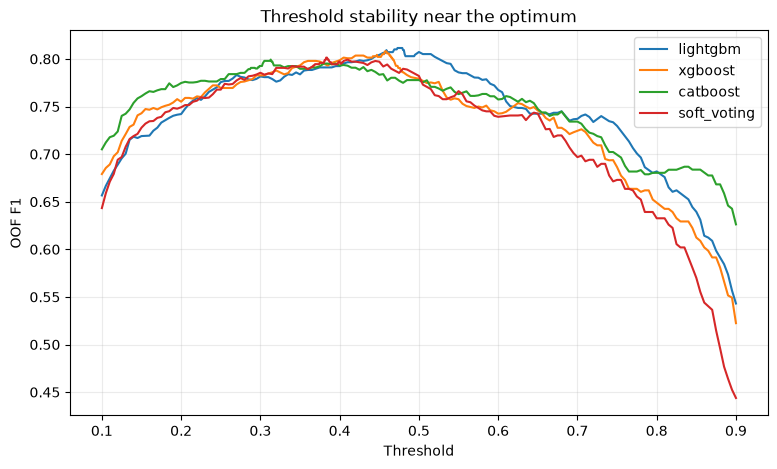

In [14]:
ensemble_parameters = {
    "models": ensemble_candidates,
    "weights": ensemble_weights,
}
ensemble_result_row = {
    "model": "soft_voting",
    "feature_set": selected_profile,
    "cv_f1_mean": ensemble_cv_f1_mean,
    "cv_f1_std": ensemble_cv_f1_std,
    "oof_f1_threshold_0.5": ensemble_metrics_half["f1"],
    "best_threshold": ensemble_threshold,
    "oof_f1_best_threshold": ensemble_metrics["f1"],
    "precision": ensemble_metrics["precision"],
    "recall": ensemble_metrics["recall"],
    "accuracy": ensemble_metrics["accuracy"],
    "roc_auc": ensemble_metrics["roc_auc"],
    "pr_auc": ensemble_metrics["pr_auc"],
    "positive_prediction_rate": ensemble_metrics["positive_rate"],
    "tn": ensemble_metrics["tn"],
    "fp": ensemble_metrics["fp"],
    "fn": ensemble_metrics["fn"],
    "tp": ensemble_metrics["tp"],
    "parameters": json.dumps(ensemble_parameters, ensure_ascii=False, sort_keys=True),
}

experiment_results = pd.concat(
    [single_model_results, pd.DataFrame([ensemble_result_row])], ignore_index=True
).sort_values(["oof_f1_best_threshold", "cv_f1_std"], ascending=[False, True])
display(experiment_results.reset_index(drop=True))

oof_predictions = pd.DataFrame(
    {"PassengerId": passenger_ids, "Survived": y}
)
for model_name, result in final_oof_results.items():
    threshold = result["threshold_info"]["threshold"]
    oof_predictions[f"{model_name}_oof"] = result["oof_probability"]
    oof_predictions[f"{model_name}_label"] = (
        result["oof_probability"] >= threshold
    ).astype(int)
oof_predictions["ensemble_oof"] = ensemble_oof_probability
oof_predictions["ensemble_label"] = (
    ensemble_oof_probability >= ensemble_threshold
).astype(int)
oof_seed_frames = []
for seed in CV_SEEDS:
    frame = pd.DataFrame(
        {"PassengerId": passenger_ids, "Survived": y, "seed": seed}
    )
    for model_name, result in final_oof_results.items():
        frame[f"{model_name}_oof"] = result["oof_by_seed"][seed]
    frame["ensemble_oof"] = ensemble_oof_by_seed[seed]
    oof_seed_frames.append(frame)
fold_metrics_all = pd.concat(
    [result["fold_metrics"] for result in final_oof_results.values()]
    + [ensemble_fold_metrics],
    ignore_index=True,
    sort=False,
)
seed_thresholds_all = pd.concat(
    [result["seed_thresholds"] for result in final_oof_results.values()],
    ignore_index=True,
)
ensemble_seed_thresholds = []
for seed, probability in ensemble_oof_by_seed.items():
    threshold_info = select_stable_threshold(y, probability)
    ensemble_seed_thresholds.append(
        {
            "model": "soft_voting",
            "feature_set": selected_profile,
            "seed": seed,
            "seed_best_threshold": threshold_info["threshold"],
            "seed_best_f1": threshold_info["f1"],
            "f1_at_common_threshold": classification_metrics(
                y, probability, ensemble_threshold
            )["f1"],
        }
    )
seed_thresholds_all = pd.concat(
    [seed_thresholds_all, pd.DataFrame(ensemble_seed_thresholds)], ignore_index=True
)
threshold_frames = []
for model_name, result in final_oof_results.items():
    frame = result["threshold_info"]["table"].copy()
    frame.insert(0, "model", model_name)
    threshold_frames.append(frame)
ensemble_threshold_table = ensemble_threshold_info["table"].copy()
ensemble_threshold_table.insert(0, "model", "soft_voting")
threshold_frames.append(ensemble_threshold_table)
threshold_search_results = pd.concat(threshold_frames, ignore_index=True)
fold_assignments = next(iter(final_oof_results.values()))["fold_assignments"].copy()
fold_assignments["PassengerId"] = fold_assignments["row_index"].map(
    dict(enumerate(passenger_ids))
)
fold_assignments = fold_assignments[["PassengerId", "seed", "fold"]]
selected_numeric, selected_categorical = feature_columns(selected_profile)
selected_features = pd.DataFrame(
    {
        "feature": selected_numeric + selected_categorical,
        "kind": ["numeric"] * len(selected_numeric)
        + ["categorical"] * len(selected_categorical),
    }
)
print("seed別閾値安定性")
display(seed_thresholds_all)
print("採用特徴量")
display(selected_features)

plot_models = list(single_model_results.head(3)["model"]) + ["soft_voting"]
fig, ax = plt.subplots(figsize=(9, 5))
for model_name in plot_models:
    subset = threshold_search_results[threshold_search_results["model"] == model_name]
    ax.plot(subset["threshold"], subset["f1"], label=model_name)
ax.set(xlabel="Threshold", ylabel="OOF F1", title="Threshold stability near the optimum")
ax.grid(alpha=0.25)
ax.legend()
plt.show()


## 14．全train再学習とtest予測

CVで固定した特徴量profile，パラメータ，重み，閾値を使う．必要な各モデルを全trainでseedごとに0から再学習し，test確率を平均する．testのラベルや予測分布を使ってモデル・重み・閾値を再最適化しない．


In [15]:
def fit_full_predict(
    model_name: str,
    params: dict[str, Any],
    profile_key: str,
    seeds: tuple[int, ...],
) -> np.ndarray:
    test_probabilities = []
    for seed in seeds:
        effective_params = params.copy()
        if (
            model_name == "xgboost"
            and effective_params.get("class_weight_mode", "none") == "balanced"
        ):
            counts = y.value_counts()
            effective_params["_positive_weight"] = float(
                counts.get(0, 0) / max(counts.get(1, 0), 1)
            )

        if model_name == "catboost":
            transformer = TitanicFeatureEngineer(profile_key=profile_key)
            transformed_train = transformer.fit_transform(X, y)
            transformed_test = transformer.transform(X_test)
            _, categorical_columns = feature_columns(profile_key)
            model = make_estimator(model_name, effective_params, seed)
            model.fit(transformed_train, y, cat_features=categorical_columns)
            probability = positive_probability(model, transformed_test)
        else:
            pipeline = make_sklearn_pipeline(
                model_name, effective_params, profile_key, seed
            )
            pipeline.fit(X, y)
            probability = positive_probability(pipeline, X_test)
        test_probabilities.append(probability)
        gc.collect()
    return np.mean(np.vstack(test_probabilities), axis=0)


models_needed_for_submission = list(
    dict.fromkeys([best_single_name] + ensemble_candidates)
)
test_probability_by_model = {}
for model_name in models_needed_for_submission:
    print(f"full-train fit: {model_name}, seeds={CV_SEEDS}")
    test_probability_by_model[model_name] = fit_full_predict(
        model_name=model_name,
        params=selected_params[model_name],
        profile_key=selected_profile,
        seeds=CV_SEEDS,
    )

best_single_threshold = float(
    final_oof_results[best_single_name]["threshold_info"]["threshold"]
)
best_single_test_probability = test_probability_by_model[best_single_name]
ensemble_test_probability = sum(
    ensemble_weights[name] * test_probability_by_model[name]
    for name in ensemble_candidates
)

print(
    f"best single: {best_single_name}, threshold={best_single_threshold:.3f}, "
    f"OOF F1={final_oof_results[best_single_name]['metrics']['f1']:.4f}"
)
print(
    f"soft voting: {ensemble_candidates}, threshold={ensemble_threshold:.3f}, "
    f"OOF F1={ensemble_metrics['f1']:.4f}"
)


full-train fit: lightgbm, seeds=(42, 123, 2026)
full-train fit: random_forest, seeds=(42, 123, 2026)
full-train fit: logistic, seeds=(42, 123, 2026)
best single: lightgbm, threshold=0.474, OOF F1=0.8115
soft voting: ['lightgbm', 'random_forest', 'logistic'], threshold=0.384, OOF F1=0.8014


## 15．Applicability Domain用特徴量と全train基準のAD判定

ADは，評価対象が学習データと似た説明変数領域にあるかを表す目安である．ここではカテゴリ変数を使わず，`Pclass`，`Age`，`FareLog`，`FamilySize`，`TicketGroupSize`，`SurnameGroupSize` の6変数だけを用いる．

`FareLog = log(1 + Fare)`，`FamilySize = SibSp + Parch + 1` とする．TicketとSurnameの件数もtrain側だけで集計し，testの未知値は1件として扱う．その後，train中央値による補完，trainだけにfitした標準化を行う．距離には5近傍の平均を使い，trainでは自分自身を除外する．train距離の95パーセンタイルを共通のAD境界とする．


In [16]:
from sklearn.neighbors import NearestNeighbors

AD_FEATURES = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "TicketGroupSize",
    "SurnameGroupSize",
]
AD_K = 5
AD_PERCENTILE = 95


def build_ad_feature_pair(
    reference: pd.DataFrame,
    target: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """referenceだけでグループ件数を学び，AD用の6特徴量を作る．"""
    reference_ticket = normalize_ticket(reference["Ticket"])
    target_ticket = normalize_ticket(target["Ticket"])
    reference_surname = extract_surname(reference["Name"])
    target_surname = extract_surname(target["Name"])
    ticket_counts = reference_ticket.value_counts()
    surname_counts = reference_surname.value_counts()

    def make_features(
        frame: pd.DataFrame,
        normalized_ticket: pd.Series,
        normalized_surname: pd.Series,
    ) -> pd.DataFrame:
        fare = pd.to_numeric(frame["Fare"], errors="coerce")
        sibsp = pd.to_numeric(frame["SibSp"], errors="coerce")
        parch = pd.to_numeric(frame["Parch"], errors="coerce")
        if fare.dropna().lt(0).any():
            raise ValueError("Fareに負の値があるためlog1pを計算できません．")
        features = pd.DataFrame(index=frame.index)
        features["Pclass"] = pd.to_numeric(frame["Pclass"], errors="coerce")
        features["Age"] = pd.to_numeric(frame["Age"], errors="coerce")
        features["FareLog"] = np.log1p(fare)
        features["FamilySize"] = sibsp + parch + 1
        features["TicketGroupSize"] = (
            normalized_ticket.map(ticket_counts).fillna(1).astype(float)
        )
        features["SurnameGroupSize"] = (
            normalized_surname.map(surname_counts).fillna(1).astype(float)
        )
        return features[AD_FEATURES]

    return (
        make_features(reference, reference_ticket, reference_surname),
        make_features(target, target_ticket, target_surname),
    )


def validate_and_save_csv(frame: pd.DataFrame, file_name: str) -> Path:
    """既存の異なる内容を上書きせず，CSVを保存して読み戻す．"""
    output_path = SUBMISSION_DIR / file_name
    normalized = frame.reset_index(drop=True)
    if output_path.exists():
        existing = pd.read_csv(output_path)
        try:
            pd.testing.assert_frame_equal(
                existing,
                normalized,
                check_dtype=False,
                check_exact=False,
                rtol=1e-9,
                atol=1e-12,
            )
        except AssertionError as error:
            raise FileExistsError(
                f"既存ファイル {output_path.name} と新しい結果が異なります．"
                "上書きせず停止しました．"
            ) from error
        print(f"{output_path.name}: 同一内容のため上書きを省略")
    else:
        normalized.to_csv(output_path, index=False, encoding="utf-8")
        print(f"{output_path.name}: 保存完了")
    reloaded = pd.read_csv(output_path)
    pd.testing.assert_frame_equal(
        reloaded,
        normalized,
        check_dtype=False,
        check_exact=False,
        rtol=1e-9,
        atol=1e-12,
    )
    return output_path


train_ad_raw, test_ad_raw = build_ad_feature_pair(X, X_test)
ad_imputer = SimpleImputer(strategy="median")
ad_scaler = StandardScaler()
X_train_ad_imputed = ad_imputer.fit_transform(train_ad_raw)
X_train_ad_scaled = ad_scaler.fit_transform(X_train_ad_imputed)
X_test_ad_imputed = ad_imputer.transform(test_ad_raw)
X_test_ad_scaled = ad_scaler.transform(X_test_ad_imputed)

train_knn = NearestNeighbors(n_neighbors=AD_K + 1)
train_knn.fit(X_train_ad_scaled)
train_distances, _ = train_knn.kneighbors(X_train_ad_scaled)
train_knn_mean_distance = train_distances[:, 1:].mean(axis=1)
ad_threshold = float(np.percentile(train_knn_mean_distance, AD_PERCENTILE))
train_ad_inside = train_knn_mean_distance <= ad_threshold

test_knn = NearestNeighbors(n_neighbors=AD_K)
test_knn.fit(X_train_ad_scaled)
test_distances, _ = test_knn.kneighbors(X_test_ad_scaled)
test_knn_mean_distance = test_distances.mean(axis=1)
test_ad_inside = test_knn_mean_distance <= ad_threshold

train_ad_results = pd.DataFrame(
    {
        "PassengerId": passenger_ids.to_numpy(),
        "knn_mean_distance": train_knn_mean_distance,
        "ad_threshold": ad_threshold,
        "AD_status": np.where(train_ad_inside, "AD内", "AD外"),
    }
)
test_ad_results = pd.DataFrame(
    {
        "PassengerId": test_passenger_ids.to_numpy(),
        "knn_mean_distance": test_knn_mean_distance,
        "ad_threshold": ad_threshold,
        "AD_status": np.where(test_ad_inside, "AD内", "AD外"),
    }
)

train_ad_inside_ratio = float(train_ad_inside.mean())
train_ad_outside_ratio = 1.0 - train_ad_inside_ratio
test_ad_inside_ratio = float(test_ad_inside.mean())
test_ad_outside_ratio = 1.0 - test_ad_inside_ratio

print(f"AD境界値（train 95パーセンタイル）: {ad_threshold:.6f}")
print(
    f"train: AD内 {train_ad_inside.sum()}件 ({train_ad_inside_ratio:.2%}), "
    f"AD外 {(~train_ad_inside).sum()}件 ({train_ad_outside_ratio:.2%})"
)
print(
    f"test : AD内 {test_ad_inside.sum()}件 ({test_ad_inside_ratio:.2%}), "
    f"AD外 {(~test_ad_inside).sum()}件 ({test_ad_outside_ratio:.2%})"
)
print("trainのkNN平均距離の要約統計量")
display(pd.Series(train_knn_mean_distance, name="train_knn_mean_distance").describe())
print("testのkNN平均距離の要約統計量")
display(pd.Series(test_knn_mean_distance, name="test_knn_mean_distance").describe())

ad_train_path = validate_and_save_csv(train_ad_results, "ad_results_train.csv")
ad_test_path = validate_and_save_csv(test_ad_results, "ad_results_test.csv")


AD境界値（train 95パーセンタイル）: 1.242118
train: AD内 676件 (94.94%), AD外 36件 (5.06%)
test : AD内 167件 (93.30%), AD外 12件 (6.70%)
trainのkNN平均距離の要約統計量


count    712.000000
mean       0.441771
std        0.472648
min        0.000000
25%        0.077110
50%        0.282532
75%        0.715924
max        4.381251
Name: train_knn_mean_distance, dtype: float64

testのkNN平均距離の要約統計量


count    179.000000
mean       0.433820
std        0.453068
min        0.000000
25%        0.066070
50%        0.296494
75%        0.633723
max        2.587621
Name: test_knn_mean_distance, dtype: float64

ad_results_train.csv: 同一内容のため上書きを省略
ad_results_test.csv: 同一内容のため上書きを省略


## 16．AD距離分布とtestのAD外データ

trainとtestのk近傍平均距離を同じ横軸で比較する．赤い破線がtrainから決めたAD境界である．testのAD外については `PassengerId` と距離計算に関係する元・派生特徴量を一覧表示する．


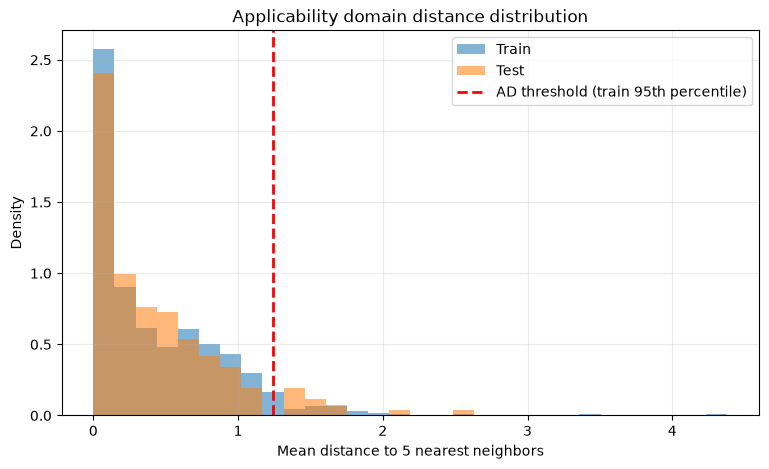

AD外となったPassengerId（12件）
[611, 148, 685, 616, 438, 639, 666, 446, 250, 499, 439, 303]
AD外データの元・派生特徴量


,PassengerId,Pclass,Age,Fare,SibSp,Parch,FareLog,FamilySize,TicketGroupSize,SurnameGroupSize,knn_mean_distance
0,439,1,64.0,263.0000,1,4,5.575949,6,3.0,3.0,2.587621
1,303,3,19.0,0.0000,0,0,0.000000,1,3.0,3.0,2.167285
2,250,2,54.0,26.0000,1,0,3.295837,2,1.0,5.0,1.633117
3,611,3,39.0,31.2750,1,5,3.474293,7,6.0,8.0,1.624343
4,438,2,24.0,18.7500,2,3,2.983153,6,2.0,2.0,1.558365
5,446,1,4.0,81.8583,0,2,4.417132,3,1.0,1.0,1.527842
6,639,3,41.0,39.6875,0,5,3.705921,6,3.0,3.0,1.504541
7,666,2,32.0,73.5000,2,0,4.310799,3,3.0,1.0,1.386307
8,685,2,60.0,39.0000,1,1,3.688879,3,1.0,1.0,1.370345
9,148,3,9.0,34.3750,2,2,3.566005,5,2.0,2.0,1.369323


In [17]:
max_distance = float(max(train_knn_mean_distance.max(), test_knn_mean_distance.max()))
histogram_bins = np.linspace(0, max_distance, 31)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    train_knn_mean_distance,
    bins=histogram_bins,
    alpha=0.55,
    density=True,
    label="Train",
)
ax.hist(
    test_knn_mean_distance,
    bins=histogram_bins,
    alpha=0.55,
    density=True,
    label="Test",
)
ax.axvline(
    ad_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label="AD threshold (train 95th percentile)",
)
ax.set(
    xlabel="Mean distance to 5 nearest neighbors",
    ylabel="Density",
    title="Applicability domain distance distribution",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

test_ad_outside_ids = test_passenger_ids.loc[~test_ad_inside].tolist()
test_ad_outside_features = test.loc[
    ~test_ad_inside,
    ["PassengerId", "Pclass", "Age", "Fare", "SibSp", "Parch"],
].copy()
for feature in ["FareLog", "FamilySize", "TicketGroupSize", "SurnameGroupSize"]:
    test_ad_outside_features[feature] = test_ad_raw.loc[~test_ad_inside, feature]
test_ad_outside_features["knn_mean_distance"] = test_knn_mean_distance[~test_ad_inside]
test_ad_outside_features = test_ad_outside_features.sort_values(
    "knn_mean_distance", ascending=False
).reset_index(drop=True)

print(f"AD外となったPassengerId（{len(test_ad_outside_ids)}件）")
print(test_ad_outside_ids)
print("AD外データの元・派生特徴量")
display(test_ad_outside_features)


## 17．fold単位のOOF用AD判定

モデル性能をAD内外に分けるときは，全train基準の簡易AD判定を流用しない．seed 42の各foldで，学習foldだけに中央値補完器・標準化器・kNNをfitし，学習fold距離の95パーセンタイルを境界として検証foldを判定する．これにより，各OOF行は自分自身を含まないデータからAD内外が決まる．

モデルのOOF確率は既存の複数seed平均をそのまま使う．AD区分だけを説明しやすい固定分割（seed 42）で一度決め，モデル間で共通に比較する．


In [18]:
def compute_fold_oof_ad(
    X_data: pd.DataFrame,
    y_data: pd.Series,
    seed: int,
) -> pd.DataFrame:
    distances = np.full(len(X_data), np.nan, dtype=float)
    thresholds = np.full(len(X_data), np.nan, dtype=float)
    statuses = np.empty(len(X_data), dtype=object)
    fold_numbers = np.zeros(len(X_data), dtype=int)
    assigned = np.zeros(len(X_data), dtype=int)

    splitter = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed,
    )
    for fold, (train_index, valid_index) in enumerate(
        splitter.split(X_data, y_data), start=1
    ):
        fold_train_raw, fold_valid_raw = build_ad_feature_pair(
            X_data.iloc[train_index],
            X_data.iloc[valid_index],
        )
        fold_imputer = SimpleImputer(strategy="median")
        fold_scaler = StandardScaler()
        fold_train_imputed = fold_imputer.fit_transform(fold_train_raw)
        fold_train_scaled = fold_scaler.fit_transform(fold_train_imputed)
        fold_valid_imputed = fold_imputer.transform(fold_valid_raw)
        fold_valid_scaled = fold_scaler.transform(fold_valid_imputed)

        fold_train_knn = NearestNeighbors(n_neighbors=AD_K + 1)
        fold_train_knn.fit(fold_train_scaled)
        fold_train_distances, _ = fold_train_knn.kneighbors(fold_train_scaled)
        fold_train_mean_distance = fold_train_distances[:, 1:].mean(axis=1)
        fold_threshold = float(
            np.percentile(fold_train_mean_distance, AD_PERCENTILE)
        )

        fold_valid_knn = NearestNeighbors(n_neighbors=AD_K)
        fold_valid_knn.fit(fold_train_scaled)
        fold_valid_distances, _ = fold_valid_knn.kneighbors(fold_valid_scaled)
        fold_valid_mean_distance = fold_valid_distances.mean(axis=1)

        distances[valid_index] = fold_valid_mean_distance
        thresholds[valid_index] = fold_threshold
        statuses[valid_index] = np.where(
            fold_valid_mean_distance <= fold_threshold, "AD内", "AD外"
        )
        fold_numbers[valid_index] = fold
        assigned[valid_index] += 1

    assert assigned.min() == assigned.max() == 1
    assert not np.isnan(distances).any()
    return pd.DataFrame(
        {
            "PassengerId": passenger_ids.to_numpy(),
            "fold": fold_numbers,
            "knn_mean_distance": distances,
            "fold_ad_threshold": thresholds,
            "AD_status": statuses,
        }
    )


oof_ad_results = compute_fold_oof_ad(X, y, seed=SEARCH_SEED)
oof_ad_inside = oof_ad_results["AD_status"].eq("AD内").to_numpy()
oof_ad_agreement_with_full_train = float(
    np.mean(oof_ad_inside == train_ad_inside)
)
oof_ad_fold_summary = (
    oof_ad_results.groupby("fold", as_index=False)
    .agg(
        Count=("PassengerId", "size"),
        AD_Threshold=("fold_ad_threshold", "first"),
        AD_Inside_Count=("AD_status", lambda values: int((values == "AD内").sum())),
    )
)
oof_ad_fold_summary["AD_Outside_Count"] = (
    oof_ad_fold_summary["Count"] - oof_ad_fold_summary["AD_Inside_Count"]
)
oof_ad_fold_summary["AD_Inside_Ratio"] = (
    oof_ad_fold_summary["AD_Inside_Count"] / oof_ad_fold_summary["Count"]
)

print(
    f"fold単位OOF AD: AD内 {oof_ad_inside.sum()}件 "
    f"({oof_ad_inside.mean():.2%}), AD外 {(~oof_ad_inside).sum()}件 "
    f"({(~oof_ad_inside).mean():.2%})"
)
print(
    "全train基準の簡易AD判定との一致率: "
    f"{oof_ad_agreement_with_full_train:.2%}"
)
display(oof_ad_fold_summary)


fold単位OOF AD: AD内 686件 (96.35%), AD外 26件 (3.65%)
全train基準の簡易AD判定との一致率: 95.79%


,fold,Count,AD_Threshold,AD_Inside_Count,AD_Outside_Count,AD_Inside_Ratio
0,1,143,1.414857,134,9,0.937063
1,2,143,1.499320,140,3,0.979021
2,3,142,1.505293,142,0,1.000000
3,4,142,1.358935,136,6,0.957746
4,5,142,1.347847,134,8,0.943662


## 18．各モデルのOOF性能をAD内外で評価

既存の8モデルとSoft VotingのOOF確率を再利用する．各モデルは既にOOF全体で決めた1個の最適閾値だけを使い，AD内専用・AD外専用の閾値は作らない．AD外は件数が少ないため，AD外F1だけでなく全体OOF F1，Precision，Recall，混同行列，件数を併記する．

`Test_AD_Weighted_Score` は，testのAD内外比率でOOFのAD内外F1を加重平均した簡易なモデル選択指標である．厳密なtest F1の予測値ではない．


In [19]:
MODEL_DISPLAY_NAMES = {
    "catboost": "CatBoost",
    "lightgbm": "LightGBM",
    "xgboost": "XGBoost",
    "hist_gradient_boosting": "HistGradientBoosting",
    "extra_trees": "Extra Trees",
    "random_forest": "Random Forest",
    "logistic": "Logistic Regression",
    "svm_rbf": "RBF-SVM",
    "soft_voting": "Soft Voting",
}

ad_oof_sources = {
    model_name: {
        "probability": result["oof_probability"],
        "threshold": float(result["threshold_info"]["threshold"]),
    }
    for model_name, result in final_oof_results.items()
}
ad_oof_sources["soft_voting"] = {
    "probability": ensemble_oof_probability,
    "threshold": float(ensemble_threshold),
}
assert {"lightgbm", "catboost", "logistic"} <= set(ad_oof_sources)


def masked_binary_metrics(
    y_true: pd.Series,
    prediction: np.ndarray,
    mask: np.ndarray,
) -> dict[str, Any]:
    subset_y = y_true.to_numpy()[mask]
    subset_prediction = np.asarray(prediction, dtype=int)[mask]
    tn, fp, fn, tp = confusion_matrix(
        subset_y, subset_prediction, labels=[0, 1]
    ).ravel()
    return {
        "F1": float(f1_score(subset_y, subset_prediction, zero_division=0)),
        "Precision": float(
            precision_score(subset_y, subset_prediction, zero_division=0)
        ),
        "Recall": float(
            recall_score(subset_y, subset_prediction, zero_division=0)
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Count": int(mask.sum()),
    }


model_ad_rows = []
for internal_name, source in ad_oof_sources.items():
    probability = np.asarray(source["probability"], dtype=float)
    threshold = float(source["threshold"])
    prediction = (probability >= threshold).astype(int)
    inside_metrics = masked_binary_metrics(y, prediction, oof_ad_inside)
    outside_metrics = masked_binary_metrics(y, prediction, ~oof_ad_inside)
    overall_f1 = float(f1_score(y, prediction, zero_division=0))
    weighted_score = (
        test_ad_inside_ratio * inside_metrics["F1"]
        + test_ad_outside_ratio * outside_metrics["F1"]
    )
    model_ad_rows.append(
        {
            "Model": MODEL_DISPLAY_NAMES[internal_name],
            "Internal_Model": internal_name,
            "Overall_OOF_F1": overall_f1,
            "AD_Inside_F1": inside_metrics["F1"],
            "AD_Outside_F1": outside_metrics["F1"],
            "AD_Inside_Precision": inside_metrics["Precision"],
            "AD_Inside_Recall": inside_metrics["Recall"],
            "AD_Outside_Precision": outside_metrics["Precision"],
            "AD_Outside_Recall": outside_metrics["Recall"],
            "AD_Inside_TP": inside_metrics["TP"],
            "AD_Inside_FP": inside_metrics["FP"],
            "AD_Inside_FN": inside_metrics["FN"],
            "AD_Inside_TN": inside_metrics["TN"],
            "AD_Outside_TP": outside_metrics["TP"],
            "AD_Outside_FP": outside_metrics["FP"],
            "AD_Outside_FN": outside_metrics["FN"],
            "AD_Outside_TN": outside_metrics["TN"],
            "AD_Inside_Count": inside_metrics["Count"],
            "AD_Outside_Count": outside_metrics["Count"],
            "Test_AD_Weighted_Score": weighted_score,
            "Best_Threshold": threshold,
        }
    )

model_ad_performance = pd.DataFrame(model_ad_rows).sort_values(
    ["Overall_OOF_F1", "Test_AD_Weighted_Score"],
    ascending=[False, False],
).reset_index(drop=True)
model_ad_performance_path = validate_and_save_csv(
    model_ad_performance,
    "model_ad_performance.csv",
)

selection_score_table = model_ad_performance[
    [
        "Model",
        "Overall_OOF_F1",
        "AD_Inside_F1",
        "AD_Outside_F1",
        "Test_AD_Weighted_Score",
        "Best_Threshold",
    ]
]
display(selection_score_table)
print("AD内外のPrecision・Recall・混同行列・件数")
display(model_ad_performance)


model_ad_performance.csv: 同一内容のため上書きを省略


,Model,Overall_OOF_F1,AD_Inside_F1,AD_Outside_F1,Test_AD_Weighted_Score,Best_Threshold
0,LightGBM,0.811490,0.813996,0.714286,0.807312,0.474
1,XGBoost,0.807899,0.810313,0.714286,0.803875,0.458
2,Soft Voting,0.801382,0.804965,0.666667,0.795693,0.384
3,CatBoost,0.797963,0.802792,0.625000,0.790873,0.309
4,Random Forest,0.790460,0.794376,0.666667,0.785815,0.346
5,Logistic Regression,0.790441,0.792453,0.714286,0.787213,0.479
6,HistGradientBoosting,0.789207,0.792388,0.666667,0.783959,0.291
7,RBF-SVM,0.787375,0.793814,0.600000,0.780821,0.296
8,Extra Trees,0.782609,0.790295,0.571429,0.775622,0.435


AD内外のPrecision・Recall・混同行列・件数


,Model,Internal_Model,Overall_OOF_F1,AD_Inside_F1,AD_Outside_F1,AD_Inside_Precision,AD_Inside_Recall,AD_Outside_Precision,AD_Outside_Recall,AD_Inside_TP,...,AD_Inside_FN,AD_Inside_TN,AD_Outside_TP,AD_Outside_FP,AD_Outside_FN,AD_Outside_TN,AD_Inside_Count,AD_Outside_Count,Test_AD_Weighted_Score,Best_Threshold
0,LightGBM,lightgbm,0.811490,0.813996,0.714286,0.792115,0.837121,1.000000,0.555556,221,...,43,364,5,0,4,17,686,26,0.807312,0.474
1,XGBoost,xgboost,0.807899,0.810313,0.714286,0.788530,0.833333,1.000000,0.555556,220,...,44,363,5,0,4,17,686,26,0.803875,0.458
2,Soft Voting,soft_voting,0.801382,0.804965,0.666667,0.756667,0.859848,0.833333,0.555556,227,...,37,349,5,1,4,16,686,26,0.795693,0.384
3,CatBoost,catboost,0.797963,0.802792,0.625000,0.744337,0.871212,0.714286,0.555556,230,...,34,343,5,2,4,15,686,26,0.790873,0.309
4,Random Forest,random_forest,0.790460,0.794376,0.666667,0.740984,0.856061,0.666667,0.666667,226,...,38,343,6,3,3,14,686,26,0.785815,0.346
5,Logistic Regression,logistic,0.790441,0.792453,0.714286,0.789474,0.795455,1.000000,0.555556,210,...,54,366,5,0,4,17,686,26,0.787213,0.479
6,HistGradientBoosting,hist_gradient_boosting,0.789207,0.792388,0.666667,0.729299,0.867424,0.833333,0.555556,229,...,35,337,5,1,4,16,686,26,0.783959,0.291
7,RBF-SVM,svm_rbf,0.787375,0.793814,0.600000,0.726415,0.875000,0.545455,0.666667,231,...,33,335,6,5,3,12,686,26,0.780821,0.296
8,Extra Trees,extra_trees,0.782609,0.790295,0.571429,0.728435,0.863636,0.500000,0.666667,228,...,36,337,6,6,3,11,686,26,0.775622,0.435


## 19．全体OOF F1とtestのAD構成によるモデル選択

提出1は全体OOF F1が最大のモデルとする．提出2は，全体OOF F1が最良値から0.02以内の候補に限定し，`Test_AD_Weighted_Score` が最大のモデルを選ぶ．提出1と同じモデルになった場合は，候補内で同スコアが2番目に高い別モデルを優先する．適切な別モデルがない場合だけ，同じモデルの閾値を0.02高くする．

提出3の本命モデルは提出1・2のうち，`(Overall_OOF_F1 + Test_AD_Weighted_Score) / 2` が高い方とする．そのOOF最適閾値を0.03下げ，Recall寄りの予測を作る．


In [20]:
best_overall_f1 = float(model_ad_performance["Overall_OOF_F1"].max())
submission_1_row = (
    model_ad_performance.sort_values(
        ["Overall_OOF_F1", "Test_AD_Weighted_Score"],
        ascending=[False, False],
    )
    .iloc[0]
    .copy()
)

candidate_models = model_ad_performance[
    model_ad_performance["Overall_OOF_F1"] >= best_overall_f1 - 0.02
].copy()
ad_ranked_candidates = candidate_models.sort_values(
    ["Test_AD_Weighted_Score", "Overall_OOF_F1"],
    ascending=[False, False],
).reset_index(drop=True)
submission_2_row = ad_ranked_candidates.iloc[0].copy()
submission_2_threshold_override = None
submission_2_selection_reason = "候補内のTest AD加重スコア1位"

if submission_2_row["Internal_Model"] == submission_1_row["Internal_Model"]:
    alternative_rows = ad_ranked_candidates[
        ad_ranked_candidates["Internal_Model"]
        != submission_1_row["Internal_Model"]
    ]
    if not alternative_rows.empty:
        submission_2_row = alternative_rows.iloc[0].copy()
        submission_2_selection_reason = (
            "提出1と同一になるため，候補内のTest AD加重スコア2位の別モデル"
        )
    else:
        submission_2_threshold_override = float(
            min(submission_2_row["Best_Threshold"] + 0.02, 1.0)
        )
        submission_2_selection_reason = (
            "適切な別モデルがないため，最良モデルの閾値を0.02上げた構成"
        )

submission_1_internal = str(submission_1_row["Internal_Model"])
submission_2_internal = str(submission_2_row["Internal_Model"])
submission_1_threshold = float(submission_1_row["Best_Threshold"])
submission_2_threshold = float(
    submission_2_threshold_override
    if submission_2_threshold_override is not None
    else submission_2_row["Best_Threshold"]
)

main_candidate_rows = model_ad_performance[
    model_ad_performance["Internal_Model"].isin(
        {submission_1_internal, submission_2_internal}
    )
].copy()
main_candidate_rows["Combined_Selection_Score"] = 0.5 * (
    main_candidate_rows["Overall_OOF_F1"]
    + main_candidate_rows["Test_AD_Weighted_Score"]
)
submission_3_row = main_candidate_rows.sort_values(
    ["Combined_Selection_Score", "Overall_OOF_F1"],
    ascending=[False, False],
).iloc[0]
submission_3_internal = str(submission_3_row["Internal_Model"])
submission_3_base_threshold = float(submission_3_row["Best_Threshold"])
submission_3_threshold = max(submission_3_base_threshold - 0.03, 0.0)


def get_selected_test_probability(internal_name: str) -> np.ndarray:
    if internal_name == "soft_voting":
        return ensemble_test_probability
    if internal_name not in test_probability_by_model:
        print(f"AD選択提出用のfull-train fit: {internal_name}, seeds={CV_SEEDS}")
        test_probability_by_model[internal_name] = fit_full_predict(
            model_name=internal_name,
            params=selected_params[internal_name],
            profile_key=selected_profile,
            seeds=CV_SEEDS,
        )
    return test_probability_by_model[internal_name]


submission_metadata = {
    "submission_1_best_overall.csv": {
        "model": MODEL_DISPLAY_NAMES[submission_1_internal],
        "internal_model": submission_1_internal,
        "threshold": submission_1_threshold,
        "probability": get_selected_test_probability(submission_1_internal),
        "selection": "全体OOF F1最良",
    },
    "submission_2_ad_selected.csv": {
        "model": MODEL_DISPLAY_NAMES[submission_2_internal],
        "internal_model": submission_2_internal,
        "threshold": submission_2_threshold,
        "probability": get_selected_test_probability(submission_2_internal),
        "selection": submission_2_selection_reason,
    },
    "submission_3_threshold_variant.csv": {
        "model": MODEL_DISPLAY_NAMES[submission_3_internal],
        "internal_model": submission_3_internal,
        "threshold": submission_3_threshold,
        "probability": get_selected_test_probability(submission_3_internal),
        "selection": "総合本命モデルのOOF最適閾値から0.03低下",
    },
}

print("全体OOF F1から0.02以内の候補")
display(
    ad_ranked_candidates[
        [
            "Model",
            "Overall_OOF_F1",
            "AD_Inside_F1",
            "AD_Outside_F1",
            "Test_AD_Weighted_Score",
            "Best_Threshold",
        ]
    ]
)
for file_name, metadata in submission_metadata.items():
    print(
        f"{file_name}: {metadata['model']}, "
        f"threshold={metadata['threshold']:.3f}, {metadata['selection']}"
    )


AD選択提出用のfull-train fit: xgboost, seeds=(42, 123, 2026)
全体OOF F1から0.02以内の候補


,Model,Overall_OOF_F1,AD_Inside_F1,AD_Outside_F1,Test_AD_Weighted_Score,Best_Threshold
0,LightGBM,0.811490,0.813996,0.714286,0.807312,0.474
1,XGBoost,0.807899,0.810313,0.714286,0.803875,0.458
2,Soft Voting,0.801382,0.804965,0.666667,0.795693,0.384
3,CatBoost,0.797963,0.802792,0.625000,0.790873,0.309


submission_1_best_overall.csv: LightGBM, threshold=0.474, 全体OOF F1最良
submission_2_ad_selected.csv: XGBoost, threshold=0.458, 提出1と同一になるため，候補内のTest AD加重スコア2位の別モデル
submission_3_threshold_variant.csv: LightGBM, threshold=0.444, 総合本命モデルのOOF最適閾値から0.03低下


## 20．3種類の提出CSV作成

3提出はtestの行順を維持し，`PassengerId` と0/1の `Survived` だけをUTF-8で保存する．同名ファイルが既に存在して内容が異なる場合は，上書きせず停止する．


In [21]:
def validate_and_save_submission(
    file_name: str,
    probability: np.ndarray,
    threshold: float,
) -> tuple[Path, np.ndarray]:
    prediction = (np.asarray(probability, dtype=float) >= threshold).astype(int)
    submission = pd.DataFrame(
        {
            "PassengerId": test_passenger_ids.to_numpy(),
            "Survived": prediction,
        }
    )
    assert list(submission.columns) == ["PassengerId", "Survived"]
    assert len(submission) == len(test) == 179
    assert submission["PassengerId"].equals(test_passenger_ids.reset_index(drop=True))
    assert not submission["PassengerId"].duplicated().any()
    assert not submission.isna().any().any()
    assert set(submission["Survived"].unique()) <= {0, 1}
    assert pd.api.types.is_integer_dtype(submission["Survived"])
    path = validate_and_save_csv(submission, file_name)
    print(f"検証完了: {path.resolve()} (UTF-8, {len(submission)} rows)")
    return path, prediction


submission_paths = []
submission_predictions = {}
for file_name, metadata in submission_metadata.items():
    path, prediction = validate_and_save_submission(
        file_name=file_name,
        probability=metadata["probability"],
        threshold=float(metadata["threshold"]),
    )
    submission_paths.append(path)
    submission_predictions[file_name] = prediction
assert len(submission_paths) == 3


submission_1_best_overall.csv: 同一内容のため上書きを省略
検証完了: /Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/submission_1_best_overall.csv (UTF-8, 179 rows)
submission_2_ad_selected.csv: 同一内容のため上書きを省略
検証完了: /Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/submission_2_ad_selected.csv (UTF-8, 179 rows)
submission_3_threshold_variant.csv: 同一内容のため上書きを省略
検証完了: /Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/submission_3_threshold_variant.csv (UTF-8, 179 rows)


## 21．3提出の比較

各提出の生存・死亡予測数と率を確認し，提出ペアごとに予測ラベルの一致率，相違する `PassengerId`，相違がtestのAD内外のどちらで生じたかを集計する．比較結果を見て乗客単位のラベルは変更しない．


In [22]:
submission_label_frame = pd.DataFrame(
    {"PassengerId": test_passenger_ids.to_numpy()}
)
for file_name, prediction in submission_predictions.items():
    submission_label_frame[Path(file_name).stem] = prediction

submission_summary_rows = []
for file_name, metadata in submission_metadata.items():
    column = Path(file_name).stem
    prediction = submission_label_frame[column].to_numpy()
    submission_summary_rows.append(
        {
            "Submission": file_name,
            "Model": metadata["model"],
            "Threshold": float(metadata["threshold"]),
            "Survived_Count": int(prediction.sum()),
            "Dead_Count": int((prediction == 0).sum()),
            "Survived_Rate": float(prediction.mean()),
            "Selection": metadata["selection"],
        }
    )
submission_summary = pd.DataFrame(submission_summary_rows)

submission_pair_rows = []
for first_file, second_file in itertools.combinations(
    submission_metadata.keys(), 2
):
    first_column = Path(first_file).stem
    second_column = Path(second_file).stem
    first_prediction = submission_label_frame[first_column].to_numpy()
    second_prediction = submission_label_frame[second_column].to_numpy()
    different = first_prediction != second_prediction
    different_ids = test_passenger_ids.loc[different].tolist()
    first_meta = submission_metadata[first_file]
    second_meta = submission_metadata[second_file]
    submission_pair_rows.append(
        {
            "Submission_A": first_file,
            "Model_A": first_meta["model"],
            "Threshold_A": float(first_meta["threshold"]),
            "Survived_Count_A": int(first_prediction.sum()),
            "Dead_Count_A": int((first_prediction == 0).sum()),
            "Survived_Rate_A": float(first_prediction.mean()),
            "Submission_B": second_file,
            "Model_B": second_meta["model"],
            "Threshold_B": float(second_meta["threshold"]),
            "Survived_Count_B": int(second_prediction.sum()),
            "Dead_Count_B": int((second_prediction == 0).sum()),
            "Survived_Rate_B": float(second_prediction.mean()),
            "Agreement_Rate": float((~different).mean()),
            "Different_Count": int(different.sum()),
            "Different_PassengerId": (
                "|".join(map(str, different_ids)) if different_ids else "なし"
            ),
            "AD_Inside_Different_Count": int(
                np.sum(different & test_ad_inside)
            ),
            "AD_Outside_Different_Count": int(
                np.sum(different & ~test_ad_inside)
            ),
        }
    )
submission_pair_comparison = pd.DataFrame(submission_pair_rows)
submission_comparison_path = validate_and_save_csv(
    submission_pair_comparison,
    "submission_comparison.csv",
)

submission_columns = [
    column for column in submission_label_frame if column != "PassengerId"
]
any_difference = submission_label_frame[submission_columns].nunique(axis=1).gt(1)
differing_passengers = test_ad_results.loc[
    any_difference,
    ["PassengerId", "AD_status", "knn_mean_distance"],
].copy()
for column in submission_columns:
    differing_passengers[column] = submission_label_frame.loc[
        any_difference, column
    ].to_numpy()
differing_passengers = differing_passengers.reset_index(drop=True)

print("各提出の予測分布")
display(submission_summary)
print("提出ペアの一致率・相違PassengerId・AD内外別相違人数")
display(submission_pair_comparison)
print(
    f"少なくとも1提出で予測が異なるPassengerId: "
    f"{len(differing_passengers)}件"
)
print(differing_passengers["PassengerId"].tolist())
display(differing_passengers)


submission_comparison.csv: 同一内容のため上書きを省略
各提出の予測分布


,Submission,Model,Threshold,Survived_Count,Dead_Count,Survived_Rate,Selection
0,submission_1_best_overall.csv,LightGBM,0.474,62,117,0.346369,全体OOF F1最良
1,submission_2_ad_selected.csv,XGBoost,0.458,62,117,0.346369,提出1と同一になるため，候補内のTest AD加重スコア2位の別モデル
2,submission_3_threshold_variant.csv,LightGBM,0.444,65,114,0.363128,総合本命モデルのOOF最適閾値から0.03低下


提出ペアの一致率・相違PassengerId・AD内外別相違人数


,Submission_A,Model_A,Threshold_A,Survived_Count_A,Dead_Count_A,Survived_Rate_A,Submission_B,Model_B,Threshold_B,Survived_Count_B,Dead_Count_B,Survived_Rate_B,Agreement_Rate,Different_Count,Different_PassengerId,AD_Inside_Different_Count,AD_Outside_Different_Count
0,submission_1_best_overall.csv,LightGBM,0.474,62,117,0.346369,submission_2_ad_selected.csv,XGBoost,0.458,62,117,0.346369,0.988827,2,883|605,2,0
1,submission_1_best_overall.csv,LightGBM,0.474,62,117,0.346369,submission_3_threshold_variant.csv,LightGBM,0.444,65,114,0.363128,0.983240,3,285|225|883,3,0
2,submission_2_ad_selected.csv,XGBoost,0.458,62,117,0.346369,submission_3_threshold_variant.csv,LightGBM,0.444,65,114,0.363128,0.983240,3,285|225|605,3,0


少なくとも1提出で予測が異なるPassengerId: 4件
[285, 225, 883, 605]


,PassengerId,AD_status,knn_mean_distance,submission_1_best_overall,submission_2_ad_selected,submission_3_threshold_variant
0,285,AD内,0.025492,0,0,1
1,225,AD内,0.431218,0,0,1
2,883,AD内,0.128172,0,1,1
3,605,AD内,0.233121,1,0,1


## 22．AD分析と提出選択のまとめ

以下の説明は実行結果から自動生成する．AD加重スコアはtestの正解を用いず，testのAD内外構成だけを反映した簡易指標であることに注意する．


In [23]:
performance_lines = []
for row in model_ad_performance.itertuples(index=False):
    performance_lines.append(
        f"- **{row.Model}**：全体OOF F1 {row.Overall_OOF_F1:.4f}，"
        f"AD内F1 {row.AD_Inside_F1:.4f}，AD外F1 {row.AD_Outside_F1:.4f}，"
        f"Test AD加重スコア {row.Test_AD_Weighted_Score:.4f}．"
    )

if submission_1_internal != submission_2_internal:
    ad_selection_effect = (
        f"全体性能だけでは{MODEL_DISPLAY_NAMES[submission_1_internal]}が選ばれたが，"
        f"testのAD構成を考慮した候補比較では"
        f"{MODEL_DISPLAY_NAMES[submission_2_internal]}を別案として選んだ．"
    )
else:
    ad_selection_effect = (
        "AD構成を考慮しても同じモデルが首位だったため，"
        "提出2では指定のfallback規則に従って閾値を変更した．"
    )

summary_by_file = submission_summary.set_index("Submission")
submission_difference_lines = []
for file_name, row in summary_by_file.iterrows():
    submission_difference_lines.append(
        f"- `{file_name}`：{row['Model']}，閾値 {row['Threshold']:.3f}，"
        f"生存 {int(row['Survived_Count'])}件，死亡 {int(row['Dead_Count'])}件，"
        f"生存率 {row['Survived_Rate']:.2%}．"
    )

final_configuration = {
    "ad_features": AD_FEATURES,
    "ad_k": AD_K,
    "ad_percentile": AD_PERCENTILE,
    "ad_threshold": ad_threshold,
    "test_ad_inside_ratio": test_ad_inside_ratio,
    "test_ad_outside_ratio": test_ad_outside_ratio,
    "oof_ad_seed": SEARCH_SEED,
    "submission_1_model": submission_1_internal,
    "submission_1_threshold": submission_1_threshold,
    "submission_2_model": submission_2_internal,
    "submission_2_threshold": submission_2_threshold,
    "submission_3_model": submission_3_internal,
    "submission_3_threshold": submission_3_threshold,
    "submission_files": [path.name for path in submission_paths],
    "result_files": [
        ad_train_path.name,
        ad_test_path.name,
        model_ad_performance_path.name,
        submission_comparison_path.name,
    ],
}

explanation = f"""
### 1．ADとは何か

Applicability Domain（AD）は，予測対象の説明変数が学習データと似た領域にあるかを確認する目安である．AD内は学習例に比較的近く，AD外は学習例から離れている．AD外で必ず誤るという意味ではないが，予測の根拠となる類似例が少ないため注意が必要である．

### 2．なぜ標準化するのか

`Age` と `FareLog` などは値の単位と幅が異なる．そのまま距離を測ると値の幅が大きい特徴量だけが距離を支配するため，train平均0・標準偏差1にそろえた．補完器と標準化器はtrainだけにfitし，同じ変換をtestへ適用した．

### 3．なぜk近傍平均距離を使うのか

最も近い1点だけでは偶然の類似に影響されやすい．近い5点までの距離を平均すると，周囲に複数の学習例があるかを単純かつ安定して表せる．trainでは自分自身の距離0を除外し，testはtrainだけを近傍候補にした．

### 4．なぜtrainの95パーセンタイルを境界にするのか

trainの大部分である95%を基準領域とし，距離が特に大きい約5%をAD外とする説明しやすい経験的境界である．今回の境界値は **{ad_threshold:.6f}** であった．絶対的な安全境界ではないため，AD外件数と性能を併記して判断する．

### 5．testのAD内外比率

testはAD内 **{int(test_ad_inside.sum())}件（{test_ad_inside_ratio:.2%}）**，AD外 **{int((~test_ad_inside).sum())}件（{test_ad_outside_ratio:.2%}）** であった．

### 6．各モデルのAD内外性能

OOF性能のAD区分は，seed {SEARCH_SEED}のfoldごとに学習foldだけから判定した．AD内は {int(oof_ad_inside.sum())}件，AD外は {int((~oof_ad_inside).sum())}件であり，AD外F1は少数例による変動が大きい点に注意する．

{chr(10).join(performance_lines)}

### 7．提出1

全体OOF F1が最も高い **{MODEL_DISPLAY_NAMES[submission_1_internal]}** を選び，OOF最適閾値 **{submission_1_threshold:.3f}** を使用した．

### 8．提出2

最良OOF F1から0.02以内の候補に限定し，**{MODEL_DISPLAY_NAMES[submission_2_internal]}** を閾値 **{submission_2_threshold:.3f}** で使用した．選定理由は「{submission_2_selection_reason}」である．

### 9．AD分析でモデル選択がどう変わったか

{ad_selection_effect} Test AD加重スコアは厳密なtest F1予測値ではなく，testのAD内外比率をモデル比較へ反映するための補助指標である．

### 10．3提出の違い

{chr(10).join(submission_difference_lines)}

提出3は全体OOF F1とTest AD加重スコアの平均が高い本命モデルを使い，基準閾値から0.03下げて生存側のRecallを重視した．具体的な一致率，相違する `PassengerId`，AD内外別の相違人数は `submission_comparison.csv` に保存した．
"""
display(Markdown(explanation))

print("生成ファイル")
for path in [
    *submission_paths,
    ad_train_path,
    ad_test_path,
    model_ad_performance_path,
    submission_comparison_path,
]:
    print(path.resolve())



### 1．ADとは何か

Applicability Domain（AD）は，予測対象の説明変数が学習データと似た領域にあるかを確認する目安である．AD内は学習例に比較的近く，AD外は学習例から離れている．AD外で必ず誤るという意味ではないが，予測の根拠となる類似例が少ないため注意が必要である．

### 2．なぜ標準化するのか

`Age` と `FareLog` などは値の単位と幅が異なる．そのまま距離を測ると値の幅が大きい特徴量だけが距離を支配するため，train平均0・標準偏差1にそろえた．補完器と標準化器はtrainだけにfitし，同じ変換をtestへ適用した．

### 3．なぜk近傍平均距離を使うのか

最も近い1点だけでは偶然の類似に影響されやすい．近い5点までの距離を平均すると，周囲に複数の学習例があるかを単純かつ安定して表せる．trainでは自分自身の距離0を除外し，testはtrainだけを近傍候補にした．

### 4．なぜtrainの95パーセンタイルを境界にするのか

trainの大部分である95%を基準領域とし，距離が特に大きい約5%をAD外とする説明しやすい経験的境界である．今回の境界値は **1.242118** であった．絶対的な安全境界ではないため，AD外件数と性能を併記して判断する．

### 5．testのAD内外比率

testはAD内 **167件（93.30%）**，AD外 **12件（6.70%）** であった．

### 6．各モデルのAD内外性能

OOF性能のAD区分は，seed 42のfoldごとに学習foldだけから判定した．AD内は 686件，AD外は 26件であり，AD外F1は少数例による変動が大きい点に注意する．

- **LightGBM**：全体OOF F1 0.8115，AD内F1 0.8140，AD外F1 0.7143，Test AD加重スコア 0.8073．
- **XGBoost**：全体OOF F1 0.8079，AD内F1 0.8103，AD外F1 0.7143，Test AD加重スコア 0.8039．
- **Soft Voting**：全体OOF F1 0.8014，AD内F1 0.8050，AD外F1 0.6667，Test AD加重スコア 0.7957．
- **CatBoost**：全体OOF F1 0.7980，AD内F1 0.8028，AD外F1 0.6250，Test AD加重スコア 0.7909．
- **Random Forest**：全体OOF F1 0.7905，AD内F1 0.7944，AD外F1 0.6667，Test AD加重スコア 0.7858．
- **Logistic Regression**：全体OOF F1 0.7904，AD内F1 0.7925，AD外F1 0.7143，Test AD加重スコア 0.7872．
- **HistGradientBoosting**：全体OOF F1 0.7892，AD内F1 0.7924，AD外F1 0.6667，Test AD加重スコア 0.7840．
- **RBF-SVM**：全体OOF F1 0.7874，AD内F1 0.7938，AD外F1 0.6000，Test AD加重スコア 0.7808．
- **Extra Trees**：全体OOF F1 0.7826，AD内F1 0.7903，AD外F1 0.5714，Test AD加重スコア 0.7756．

### 7．提出1

全体OOF F1が最も高い **LightGBM** を選び，OOF最適閾値 **0.474** を使用した．

### 8．提出2

最良OOF F1から0.02以内の候補に限定し，**XGBoost** を閾値 **0.458** で使用した．選定理由は「提出1と同一になるため，候補内のTest AD加重スコア2位の別モデル」である．

### 9．AD分析でモデル選択がどう変わったか

全体性能だけではLightGBMが選ばれたが，testのAD構成を考慮した候補比較ではXGBoostを別案として選んだ． Test AD加重スコアは厳密なtest F1予測値ではなく，testのAD内外比率をモデル比較へ反映するための補助指標である．

### 10．3提出の違い

- `submission_1_best_overall.csv`：LightGBM，閾値 0.474，生存 62件，死亡 117件，生存率 34.64%．
- `submission_2_ad_selected.csv`：XGBoost，閾値 0.458，生存 62件，死亡 117件，生存率 34.64%．
- `submission_3_threshold_variant.csv`：LightGBM，閾値 0.444，生存 65件，死亡 114件，生存率 36.31%．

提出3は全体OOF F1とTest AD加重スコアの平均が高い本命モデルを使い，基準閾値から0.03下げて生存側のRecallを重視した．具体的な一致率，相違する `PassengerId`，AD内外別の相違人数は `submission_comparison.csv` に保存した．


生成ファイル
/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/submission_1_best_overall.csv
/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/submission_2_ad_selected.csv
/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/submission_3_threshold_variant.csv
/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/ad_results_train.csv
/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/ad_results_test.csv
/Users/fu-riku/Library/CloudStorage/GoogleDrive-fukumoto.riku.fr7@g.ext.naist.jp/マイドライブ/MI_Lab_cloud/python-seminar/lesson_8/self_code/model_ad_performance.csv
/Users/fu-r

## 23．再実行時の確認

- 完全評価では `FAST_MODE=False`，`CV_SEEDS=(42, 123, 2026)` であることを確認する．
- カーネルを再起動し，上から順に全セルを実行する．
- 3提出は179行・列順・ID順・0/1・欠損なしをassertし，保存後に読み戻している．
- `ad_results_train.csv`，`ad_results_test.csv`，`model_ad_performance.csv`，`submission_comparison.csv` も保存後に読み戻している．
- OOF性能はfold単位AD判定，全trainとtestのAD比率は全train基準AD判定を使い分ける．
- testの正解配布後に評価するときも，提出CSVのラベルを人手修正せず，提出時のファイルをそのまま採点する．
